In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import sys
import io, textwrap

In [2]:
#### Trainable parameters
# lin: 4.7M
# Ortho 512: 233M; 256: 60M; 128: 18M; 64: 8M; 32: 5.5M
# LoRA: r3: 12.8M, r1: 4.3M
# Vera: 2.8M

Model matching results:
  LoRA r=1                  | BB=NOT FOUND | MMLU=NOT FOUND
  LoRA r=3                  | BB=0.6154 | MMLU=0.6990
  UIorthoLoRA s1024_v0      | BB=0.5947 | MMLU=0.6834
  UIorthoLoRA s1024_v128    | BB=0.6123 | MMLU=0.6889
  UIorthoLoRA s1024_v256    | BB=0.6093 | MMLU=0.6885
  UIorthoLoRA s1024_v32     | BB=0.6293 | MMLU=0.6775
  UIorthoLoRA s1024_v512    | BB=0.6174 | MMLU=0.6900
  UIorthoLoRA s1024_v64     | BB=0.6024 | MMLU=0.6924
  UIorthoLoRA s256_v0       | BB=0.5931 | MMLU=0.6790
  UIorthoLoRA s512_v0       | BB=0.6053 | MMLU=0.6768
  VeRA r=1024               | BB=0.6070 | MMLU=0.6606


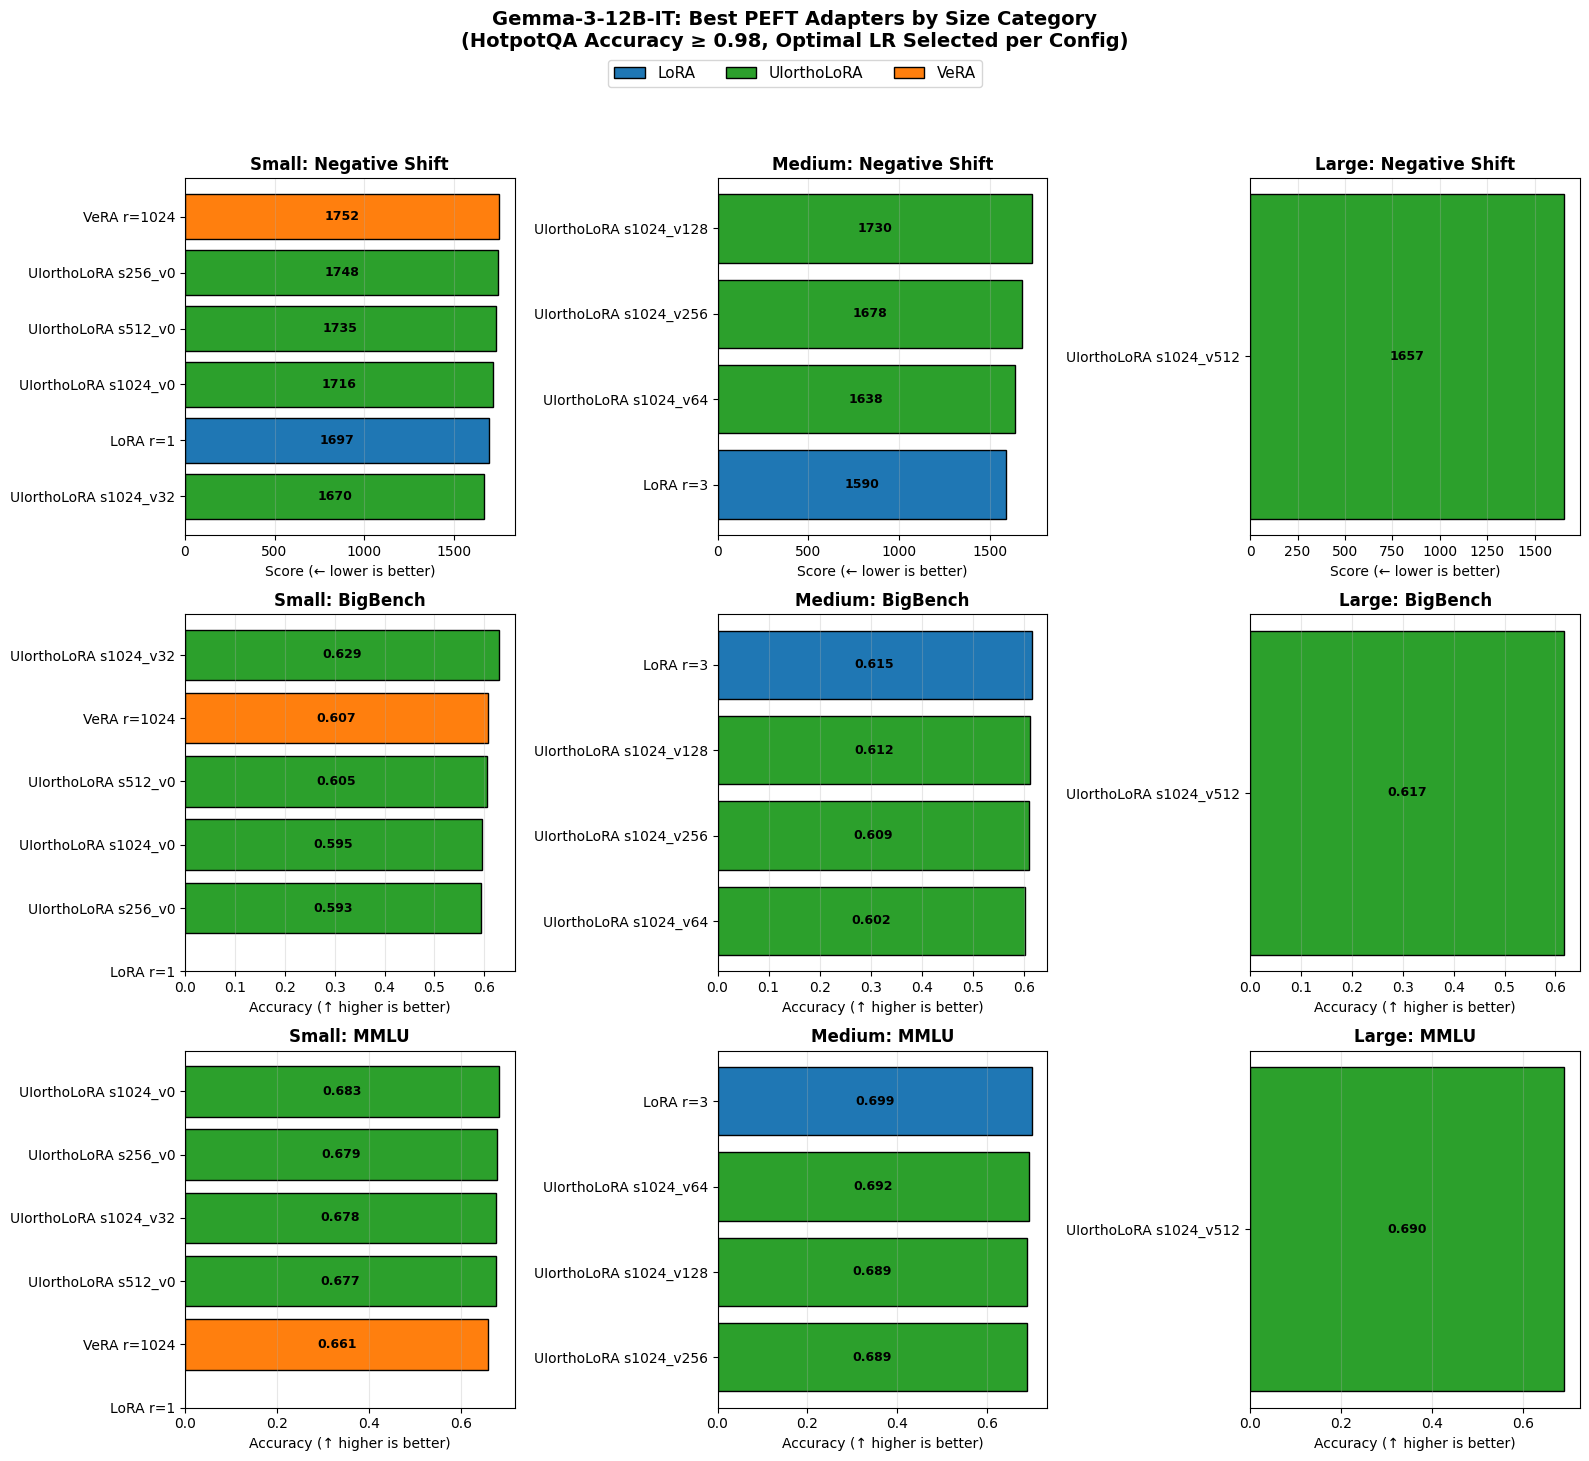

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from matplotlib.patches import Patch

# ============================================================================
# LOAD ALL DATA
# ============================================================================

# Load HotpotQA results
df = pd.read_csv("adapters_results/threshold_0.6/adapter_results_gemma-3-12b-it.csv")

# Load BigBench results
df_bigbench = pd.read_csv("../results/bigbench/summary.csv")  # Update path

# Load MMLU results
df_mmlu = pd.read_csv("../results/mmlu/mmlu_summary.csv")  # Update path

# ============================================================================
# PROCESS HOTPOTQA DATA (same as before)
# ============================================================================

for col in ["lr", "rank", "accuracy", "negative_shift_score"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df[(df['accuracy'].notna()) & (df['negative_shift_score'] > 0)].copy()

def extract_config_details(row):
    """Extract adapter name and svecs/rank for categorization."""
    name = row['raw_adapter_name']
    adapter_type = row['adapter_type']
    
    if adapter_type == 'lora':
        match = re.search(r'lora_r(\d+)', name)
        rank = int(match.group(1)) if match else None
        return f"LoRA r={rank}", rank, None
    
    elif adapter_type == 'uiortholora':
        match = re.search(r's(\d+)_v(\d+)', name)
        if match:
            svals = int(match.group(1))
            svecs = int(match.group(2))
            return f"UIorthoLoRA s{svals}_v{svecs}", None, svecs
        return "UIorthoLoRA unknown", None, None
    
    elif adapter_type == 'vera':
        match = re.search(r'vera_r(\d+)', name)
        rank = int(match.group(1)) if match else None
        return f"VeRA r={rank}", rank, None
    
    return "unknown", None, None

df[['config_label', 'rank_val', 'svecs']] = df.apply(
    lambda row: pd.Series(extract_config_details(row)), axis=1
)

def categorize_size(row):
    adapter_type = row['adapter_type']
    svecs = row['svecs']
    rank = row['rank_val']
    
    if adapter_type == 'lora':
        return 'small' if rank == 1 else 'medium' if rank == 3 else None
    elif adapter_type == 'uiortholora':
        if svecs is not None:
            if svecs <= 32: return 'small'
            elif 64 <= svecs <= 256: return 'medium'
            elif svecs >= 512: return 'large'
    elif adapter_type == 'vera':
        return 'small'
    return None

df['size_category'] = df.apply(categorize_size, axis=1)

# Filter for accuracy >= 0.98
df_qualified = df[df['accuracy'] >= 0.98].copy()

# Pick best LR per config (lowest negative_shift_score)
best_per_config = df_qualified.loc[
    df_qualified.groupby('config_label')['negative_shift_score'].idxmin()
].copy()

# ============================================================================
# CREATE MATCHING KEY FOR CROSS-BENCHMARK LOOKUP
# ============================================================================

# BigBench: model_path like "models/google_gemma-3-12b-it_lora_trAll_lora_r3_lr1e-4"
# MMLU: model_name like "models/google_gemma-3-12b-it_lora_trAll_lora_r3_lr1e-4"
# HotpotQA: raw_adapter_name like "google_gemma-3-12b-it_lora_trAll_lora_r3_lr1e-4"

# Create lookup key by stripping "models/" prefix
df_bigbench['match_key'] = df_bigbench['model_path'].str.replace('models/', '', regex=False)
df_mmlu['match_key'] = df_mmlu['model_name'].str.replace('models/', '', regex=False)

# Create lookup dictionaries
bigbench_lookup = df_bigbench.set_index('match_key')['mean_accuracy'].to_dict()
mmlu_lookup = df_mmlu.set_index('match_key')['mmlu_acc'].to_dict()

# Add BigBench and MMLU accuracy to best_per_config
best_per_config['bigbench_acc'] = best_per_config['raw_adapter_name'].map(bigbench_lookup)
best_per_config['mmlu_acc'] = best_per_config['raw_adapter_name'].map(mmlu_lookup)

# Print matching results
print("Model matching results:")
for _, row in best_per_config.iterrows():
    bb = row['bigbench_acc']
    mmlu = row['mmlu_acc']
    bb_str = f"{bb:.4f}" if pd.notna(bb) else "NOT FOUND"
    mmlu_str = f"{mmlu:.4f}" if pd.notna(mmlu) else "NOT FOUND"
    print(f"  {row['config_label']:25s} | BB={bb_str} | MMLU={mmlu_str}")

# ============================================================================
# SEPARATE BY SIZE CATEGORY
# ============================================================================

small = best_per_config[best_per_config['size_category'] == 'small'].sort_values('negative_shift_score')
medium = best_per_config[best_per_config['size_category'] == 'medium'].sort_values('negative_shift_score')
large = best_per_config[best_per_config['size_category'] == 'large'].sort_values('negative_shift_score')

# ============================================================================
# PLOTTING
# ============================================================================

colors = {'lora': '#1f77b4', 'uiortholora': '#2ca02c', 'vera': '#ff7f0e'}

fig, axes = plt.subplots(3, 3, figsize=(16, 14))

def plot_metric(ax, data, metric_col, title, xlabel, higher_better=True, show_value=True):
    """Generic plotting function for different metrics."""
    if data.empty or data[metric_col].isna().all():
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(title, fontsize=12, fontweight='bold')
        return
    
    # Sort by the metric
    data = data.sort_values(metric_col, ascending=not higher_better)
    bar_colors = [colors.get(row['adapter_type'], 'gray') for _, row in data.iterrows()]
    
    values = data[metric_col].values
    ax.barh(range(len(data)), values, color=bar_colors, edgecolor='black')
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(data['config_label'], fontsize=10)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    
    if show_value:
        for i, (_, row) in enumerate(data.iterrows()):
            val = row[metric_col]
            if pd.notna(val):
                # Value inside bar
                ax.annotate(f"{val:.3f}" if val < 10 else f"{val:.0f}", 
                            xy=(val / 2, i),
                            va='center', ha='center', fontsize=9, fontweight='bold', color='black')
    
    ax.grid(axis='x', alpha=0.3)
    if higher_better:
        ax.invert_yaxis()

# Row 0: Negative Shift Score (lower is better)
plot_metric(axes[0, 0], small, 'negative_shift_score', 
            'Small: Negative Shift', 'Score (← lower is better)', higher_better=False)
plot_metric(axes[0, 1], medium, 'negative_shift_score', 
            'Medium: Negative Shift', 'Score (← lower is better)', higher_better=False)
plot_metric(axes[0, 2], large, 'negative_shift_score', 
            'Large: Negative Shift', 'Score (← lower is better)', higher_better=False)

# Row 1: BigBench Accuracy (higher is better)
plot_metric(axes[1, 0], small, 'bigbench_acc', 
            'Small: BigBench', 'Accuracy (↑ higher is better)', higher_better=True)
plot_metric(axes[1, 1], medium, 'bigbench_acc', 
            'Medium: BigBench', 'Accuracy (↑ higher is better)', higher_better=True)
plot_metric(axes[1, 2], large, 'bigbench_acc', 
            'Large: BigBench', 'Accuracy (↑ higher is better)', higher_better=True)

# Row 2: MMLU Accuracy (higher is better)
plot_metric(axes[2, 0], small, 'mmlu_acc', 
            'Small: MMLU', 'Accuracy (↑ higher is better)', higher_better=True)
plot_metric(axes[2, 1], medium, 'mmlu_acc', 
            'Medium: MMLU', 'Accuracy (↑ higher is better)', higher_better=True)
plot_metric(axes[2, 2], large, 'mmlu_acc', 
            'Large: MMLU', 'Accuracy (↑ higher is better)', higher_better=True)

# Legend
legend_elements = [
    Patch(facecolor=colors['lora'], edgecolor='black', label='LoRA'),
    Patch(facecolor=colors['uiortholora'], edgecolor='black', label='UIorthoLoRA'),
    Patch(facecolor=colors['vera'], edgecolor='black', label='VeRA'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=3, fontsize=11, bbox_to_anchor=(0.5, 1.01))

fig.suptitle('Gemma-3-12B-IT: Best PEFT Adapters by Size Category\n'
             '(HotpotQA Accuracy ≥ 0.98, Optimal LR Selected per Config)', 
             fontsize=14, fontweight='bold', y=1.04)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import colorsys

# Optional: Ensure plots display inline if you are using an older Jupyter version
# %matplotlib inline 

# ============================================================================
# REUSABLE VISUALIZATION FUNCTIONS
# Each adapter+config combination gets its own color
# ============================================================================

def parse_model_config(model_name):
    """
    Parse model name to extract adapter type and configuration.
    """
    # Extract learning rate
    lr_match = re.search(r'_lr([0-9e\-]+)$', model_name)
    lr = lr_match.group(1) if lr_match else None
    
    # Determine adapter type
    if '_lora_' in model_name and '_uiortholora_' not in model_name and '_randlora_' not in model_name:
        adapter_type = 'lora'
    elif '_uiortholora_' in model_name:
        adapter_type = 'uiortholora'
    elif '_vera_' in model_name:
        adapter_type = 'vera'
    elif '_randlora_' in model_name:
        adapter_type = 'randlora'
    else:
        adapter_type = 'unknown'
    
    # Extract configuration based on adapter type
    config = None
    
    if adapter_type == 'lora':
        match = re.search(r'lora_r(\d+)', model_name)
        if match:
            config = f"r{match.group(1)}"
    
    elif adapter_type == 'uiortholora':
        match = re.search(r'(?:uiortholora_)?s(\d+)_v(\d+)', model_name)
        if match:
            config = f"s{match.group(1)}_v{match.group(2)}"
    
    elif adapter_type == 'vera':
        match = re.search(r'vera_r(\d+)', model_name)
        if match:
            config = f"r{match.group(1)}"
    
    elif adapter_type == 'randlora':
        match = re.search(r'randlora_r(\d+)', model_name)
        if match:
            config = f"r{match.group(1)}"
    
    return adapter_type, config, lr


def generate_color_for_config(adapter_type, config, index_in_family):
    """Generate a distinct color for an adapter+config combination."""
    # Base hues for each adapter type (0-1 range)
    base_hues = {
        'lora': 0.58,        # blue
        'uiortholora': 0.33, # green
        'vera': 0.08,        # orange
        'randlora': 0.0,     # red
    }
    
    base_hue = base_hues.get(adapter_type, 0.5)
    
    # Vary the hue slightly and saturation/lightness for different configs
    hue_offset = (index_in_family * 0.03) % 0.15  # Small hue variation
    hue = (base_hue + hue_offset) % 1.0
    
    # Vary saturation and lightness
    saturation = 0.7 + (index_in_family % 3) * 0.1  # 0.7, 0.8, 0.9
    lightness = 0.45 + (index_in_family % 4) * 0.08  # 0.45, 0.53, 0.61, 0.69
    
    r, g, b = colorsys.hls_to_rgb(hue, lightness, saturation)
    return f'#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}'


def get_config_colors(adapter_configs):
    """
    Generate colors for all adapter configs.
    Groups by adapter type to assign similar hues within families.
    """
    # Group configs by adapter type
    families = {}
    for ac in adapter_configs:
        parts = ac.split('_', 1)
        adapter_type = parts[0] if parts else 'unknown'
        if adapter_type not in families:
            families[adapter_type] = []
        families[adapter_type].append(ac)
    
    # Sort within families for consistent ordering
    for adapter_type in families:
        families[adapter_type] = sorted(families[adapter_type])
    
    # Assign colors
    colors = {}
    for adapter_type, configs in families.items():
        for i, ac in enumerate(configs):
            parts = ac.split('_', 1)
            config = parts[1] if len(parts) > 1 else ''
            colors[ac] = generate_color_for_config(adapter_type, config, i)
    
    return colors


def load_and_prepare_data(csv_path):
    """Load CSV and prepare data for visualization."""
    df = pd.read_csv(csv_path)
    
    # Convert columns to numeric
    for col in ["lr", "rank", "tr_from_name", "tr_actual", "accuracy",
                "negative_shift_count", "negative_shift_score",
                "positive_shift_count", "positive_shift_score"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    
    if "tr_actual" in df.columns and "tr_from_name" in df.columns:
        df["train_samples"] = df["tr_actual"].fillna(df["tr_from_name"])
    
    # Parse adapter_config from raw_adapter_name if available
    if 'adapter_config' not in df.columns and 'raw_adapter_name' in df.columns:
        df['adapter_config'] = df['raw_adapter_name'].apply(extract_adapter_config)
    elif 'adapter_config' not in df.columns and 'model_name' in df.columns:
        df['adapter_config'] = df['model_name'].apply(extract_adapter_config)
    elif 'adapter_config' not in df.columns and 'adapter_type' in df.columns:
        # Fallback: build from adapter_type + rank
        if 'rank' in df.columns:
            df['adapter_config'] = df.apply(
                lambda row: f"{row['adapter_type']}_r{int(row['rank'])}" if pd.notna(row.get('rank')) else row['adapter_type'],
                axis=1
            )
        else:
            df['adapter_config'] = df['adapter_type']
    
    return df


def extract_adapter_config(name):
    """
    Extract adapter config string from raw_adapter_name.
    """
    if pd.isna(name):
        return 'unknown'
    
    # Determine adapter type
    if '_lora_' in name and '_uiortholora_' not in name and '_randlora_' not in name:
        adapter_type = 'lora'
        # Extract rank: lora_r{rank}
        match = re.search(r'lora_r(\d+)', name)
        if match:
            return f"lora_r{match.group(1)}"
    
    elif '_uiortholora_' in name:
        adapter_type = 'uiortholora'
        # Extract svals/svecs: s{svals}_v{svecs} (with or without uiortholora_ prefix)
        match = re.search(r'(?:uiortholora_)?s(\d+)_v(\d+)', name)
        if match:
            return f"uiortholora_s{match.group(1)}_v{match.group(2)}"
    
    elif '_vera_' in name:
        adapter_type = 'vera'
        # Extract rank: vera_r{rank}
        match = re.search(r'vera_r(\d+)', name)
        if match:
            return f"vera_r{match.group(1)}"
    
    elif '_randlora_' in name:
        adapter_type = 'randlora'
        # Extract rank: randlora_r{rank}
        match = re.search(r'randlora_r(\d+)', name)
        if match:
            return f"randlora_r{match.group(1)}"
    
    return 'unknown'


def plot_accuracy_vs_negshift(df, output_prefix, model_name="Model", min_accuracy=0.97, max_negative=1800):
    """
    Single scatter plot: Accuracy vs Negative Shift Score
    Filters out any points with accuracy below min_accuracy.
    """
    # Filter out incomplete runs AND low accuracy runs
    df_valid = df[
        (df['negative_shift_score'] > 0) & 
        (df['accuracy'] >= min_accuracy) &
        (df['negative_shift_score'] <= max_negative)
    ].copy()
    
    if len(df_valid) < len(df):
        print(f"Filtered out {len(df) - len(df_valid)} points (Low accuracy < {min_accuracy} or incomplete)")
    
    adapter_configs = sorted(df_valid["adapter_config"].dropna().unique())
    
    # Define distinct markers for each adapter config
    markers = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'h', '<', '>', 'p']
    marker_map = {ac: markers[i % len(markers)] for i, ac in enumerate(adapter_configs)}
    
    fig, ax = plt.subplots(figsize=(12, 9))
    
    # Use log scale for LR coloring
    df_valid['log_lr'] = np.log10(df_valid['lr'])
    vmin, vmax = df_valid['log_lr'].min(), df_valid['log_lr'].max()
    
    # Plot each adapter config with its marker
    scatter = None
    for ac in adapter_configs:
        sub_ac = df_valid[df_valid["adapter_config"] == ac]
        if sub_ac.empty:
            continue
        
        marker = marker_map[ac]
        
        # Format label
        parts = ac.split('_', 1)
        label = f"{parts[0].upper()} ({parts[1]})" if len(parts) == 2 else ac.upper()
        
        scatter = ax.scatter(
            sub_ac["negative_shift_score"], 
            sub_ac["accuracy"],
            c=sub_ac["log_lr"],
            cmap='viridis_r',  # Reversed: yellow=low LR, purple=high LR
            marker=marker,
            s=150,
            alpha=0.8,
            edgecolors='black',
            linewidths=0.5,
            label=label,
            vmin=vmin,
            vmax=vmax
        )
    
    # Add colorbar for learning rate
    if scatter is not None:
        cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
        cbar.set_label('Learning Rate', fontsize=11)
        # Format colorbar ticks as actual LR values
        log_ticks = np.linspace(vmin, vmax, 6)
        cbar.set_ticks(log_ticks)
        cbar.set_ticklabels([f'{10**t:.0e}' for t in log_ticks])
    
    ax.set_xlabel("Negative Shift Score (← lower is better)", fontsize=12)
    ax.set_ylabel("Accuracy (↑ higher is better)", fontsize=12)
    ax.set_title(f'{model_name}: Accuracy vs Negative Shift Trade-off\n'
                 f'Marker = Adapter Config, Color = Learning Rate', 
                 fontsize=14, fontweight='bold')
    
    # Place legend outside plot area (to the right, below colorbar)
    ax.legend(loc='upper left', bbox_to_anchor=(1.15, 0.85), fontsize=10, framealpha=0.9)
    ax.grid(True, alpha=0.3)
    
    # Add "ideal" corner annotation
    ax.annotate('← Ideal', 
                xy=(ax.get_xlim()[0], ax.get_ylim()[1]),
                xytext=(0.02, 0.98), textcoords='axes fraction',
                fontsize=10, color='green', fontweight='bold',
                va='top', ha='left')
    
    plt.tight_layout()
    plt.show() # Display instantly
    
    return fig, ax


def plot_accuracy_vs_negshift_faceted(df, output_prefix, model_name="Model"):
    """
    Faceted plot: One subplot per adapter type, showing configs within each.
    - X: negative shift score
    - Y: accuracy  
    - Color: config within adapter type
    - Annotations: learning rate labels on points
    """
    # Filter out incomplete runs
    df_valid = df[
        (df['negative_shift_score'] > 0) & 
        (df['accuracy'].notna())
    ].copy()
    
    if len(df_valid) < len(df):
        print(f"Filtered out {len(df) - len(df_valid)} incomplete runs")
    
    # Extract adapter type from adapter_config
    df_valid['adapter_family'] = df_valid['adapter_config'].apply(lambda x: x.split('_')[0])
    
    families = sorted(df_valid['adapter_family'].unique())
    n_families = len(families)
    
    # Create subplots
    fig, axes = plt.subplots(1, n_families, figsize=(6*n_families, 6), sharey=True)
    if n_families == 1:
        axes = [axes]
    
    # Color palette for configs within each family
    family_palettes = {
        'lora': ['#1f77b4', '#4a90d9', '#7eb3e6', '#aed5f2'],
        'uiortholora': ['#2ca02c', '#5fd35f', '#8fdc8f', '#b8e8b8', '#d4f0d4'],
        'vera': ['#ff7f0e', '#ffaa4d', '#ffc78a', '#ffe0b3'],
        'randlora': ['#d62728', '#e85c5c', '#f28b8b', '#f5b5b5'],
    }
    
    for ax, family in zip(axes, families):
        df_family = df_valid[df_valid['adapter_family'] == family]
        configs = sorted(df_family['adapter_config'].unique())
        
        palette = family_palettes.get(family, plt.cm.tab10.colors)
        
        for i, config in enumerate(configs):
            df_config = df_family[df_family['adapter_config'] == config]
            color = palette[i % len(palette)]
            
            # Format label (remove family prefix)
            label_parts = config.split('_', 1)
            label = label_parts[1] if len(label_parts) > 1 else config
            
            ax.scatter(
                df_config['negative_shift_score'],
                df_config['accuracy'],
                c=color,
                s=120,
                alpha=0.8,
                edgecolors='black',
                linewidths=0.5,
                label=label
            )
            
            # Add LR annotations
            for _, row in df_config.iterrows():
                lr_str = f"{row['lr']:.0e}".replace('e-0', 'e-')
                ax.annotate(
                    lr_str,
                    (row['negative_shift_score'], row['accuracy']),
                    fontsize=7,
                    alpha=0.7,
                    xytext=(3, 3),
                    textcoords='offset points'
                )
        
        ax.set_xlabel("Negative Shift Score", fontsize=11)
        ax.set_title(f'{family.upper()}', fontsize=13, fontweight='bold')
        ax.legend(loc='best', fontsize=9)
        ax.grid(True, alpha=0.3)
    
    axes[0].set_ylabel("Accuracy", fontsize=11)
    
    fig.suptitle(f'{model_name}: Accuracy vs Negative Shift by Adapter Type', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.show() # Display instantly
    
    return fig, axes


def run_full_analysis(csv_path, output_prefix, model_name):
    """
    Run complete analysis pipeline for a given CSV file.
    Generates two plots:
    1. Single scatter with marker=config, color=LR
    2. Faceted plot by adapter family with LR annotations
    """
    print(f"\n{'='*70}")
    print(f"Running analysis for {model_name}")
    print(f"{'='*70}\n")
    
    df = load_and_prepare_data(csv_path)
    
    print(f"Loaded {len(df)} rows")
    print(f"Unique adapter configs: {df['adapter_config'].nunique()}")
    for ac in sorted(df['adapter_config'].unique()):
        count = len(df[df['adapter_config'] == ac])
        print(f"  {ac}: {count} points")
    
    plot_accuracy_vs_negshift(df, output_prefix, model_name)
    
    plot_accuracy_vs_negshift_faceted(df, output_prefix, model_name)


Running analysis for Gemma-3-12B-IT

Loaded 85 rows
Unique adapter configs: 16
  lora_r1: 3 points
  lora_r3: 11 points
  uiortholora_s1024_v0: 18 points
  uiortholora_s1024_v128: 5 points
  uiortholora_s1024_v256: 5 points
  uiortholora_s1024_v3: 1 points
  uiortholora_s1024_v32: 5 points
  uiortholora_s1024_v512: 5 points
  uiortholora_s1024_v64: 5 points
  uiortholora_s256_v0: 4 points
  uiortholora_s512_v0: 4 points
  uiortholora_s512_v128: 2 points
  uiortholora_s512_v256: 2 points
  uiortholora_s512_v32: 2 points
  uiortholora_s512_v64: 2 points
  vera_r1024: 11 points
Filtered out 50 points (Low accuracy < 0.97 or incomplete)


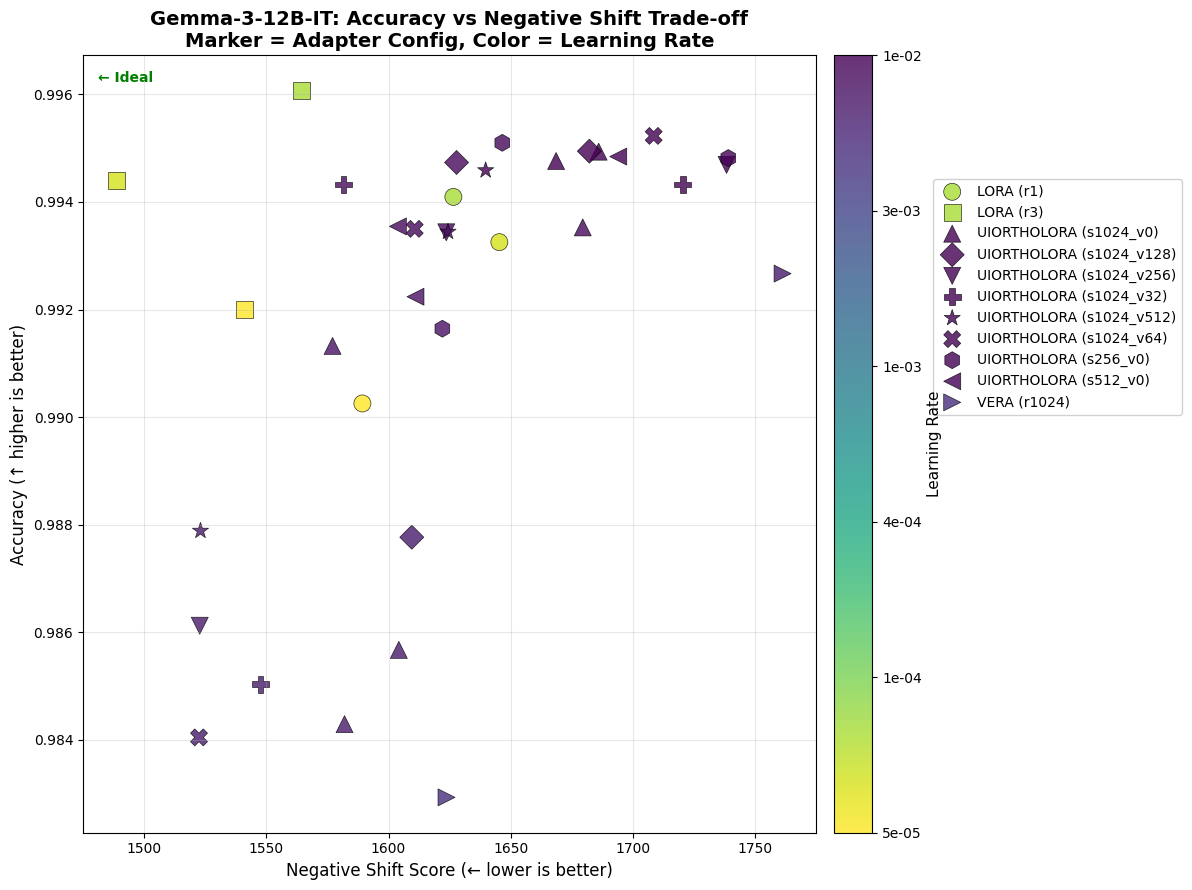

Filtered out 5 incomplete runs


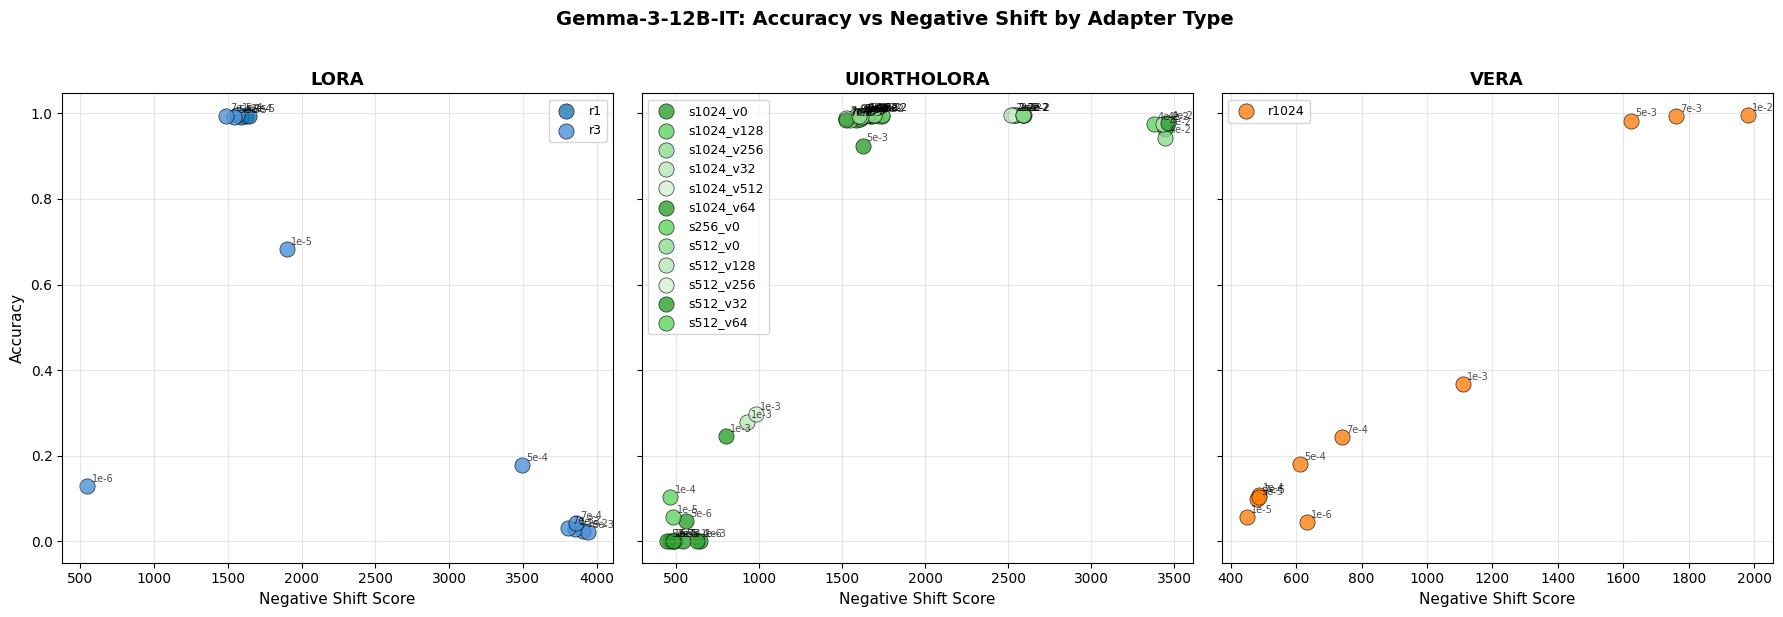

In [5]:
run_full_analysis(
    csv_path="adapters_results/threshold_0.8/adapter_results_gemma-3-12b-it.csv",
    output_prefix="graphs/gemma",
    model_name="Gemma-3-12B-IT"
)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from matplotlib.lines import Line2D

def extract_adapter_config(name):
    """Extract adapter config string from raw_adapter_name."""
    if pd.isna(name):
        return 'unknown'
    
    if '_lora_' in name and '_uiortholora_' not in name and '_randlora_' not in name:
        match = re.search(r'lora_r(\d+)', name)
        if match:
            return f"lora_r{match.group(1)}"
    
    elif '_uiortholora_' in name:
        match = re.search(r'(?:uiortholora_)?s(\d+)_v(\d+)', name)
        if match:
            return f"uiortholora_s{match.group(1)}_v{match.group(2)}"
    
    elif '_vera_' in name:
        match = re.search(r'vera_r(\d+)', name)
        if match:
            return f"vera_r{match.group(1)}"
    
    elif '_randlora_' in name:
        match = re.search(r'randlora_r(\d+)', name)
        if match:
            return f"randlora_r{match.group(1)}"
    
    return 'unknown'


def load_and_prepare_data(csv_path):
    """Load CSV and prepare data."""
    df = pd.read_csv(csv_path)
    
    for col in ["lr", "rank", "accuracy", "negative_shift_score"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    
    if 'adapter_config' not in df.columns and 'raw_adapter_name' in df.columns:
        df['adapter_config'] = df['raw_adapter_name'].apply(extract_adapter_config)
    
    df['adapter_family'] = df['adapter_config'].apply(lambda x: x.split('_')[0] if pd.notna(x) else 'unknown')
    
    return df


def get_pareto_frontier(df, x_col='negative_shift_score', y_col='accuracy'):
    """Find Pareto-optimal points (minimize x, maximize y)."""
    points = df[[x_col, y_col]].values
    pareto_mask = np.ones(len(points), dtype=bool)
    
    for i, (x_i, y_i) in enumerate(points):
        if not pareto_mask[i]:
            continue
        for j, (x_j, y_j) in enumerate(points):
            if i == j or not pareto_mask[j]:
                continue
            if x_j <= x_i and y_j >= y_i and (x_j < x_i or y_j > y_i):
                pareto_mask[i] = False
                break
    
    return df[pareto_mask].copy()


def plot_lr_trajectories(df, model_name="Model"):
    """Faceted by adapter family, showing LR trajectories for each config."""
    df_valid = df[
        (df['negative_shift_score'] > 0) & 
        (df['accuracy'].notna()) &
        (df['accuracy'] > 0)
    ].copy()
    
    families = sorted(df_valid['adapter_family'].unique())
    n_families = len(families)
    
    fig, axes = plt.subplots(1, n_families, figsize=(7*n_families, 6))
    if n_families == 1:
        axes = [axes]
    
    family_colors = {
        'lora': plt.cm.Blues,
        'uiortholora': plt.cm.Greens,
        'vera': plt.cm.Oranges,
        'randlora': plt.cm.Reds,
    }
    
    for ax, family in zip(axes, families):
        df_family = df_valid[df_valid['adapter_family'] == family]
        configs = sorted(df_family['adapter_config'].unique())
        
        cmap = family_colors.get(family, plt.cm.viridis)
        colors = [cmap(0.3 + 0.6 * i / max(len(configs)-1, 1)) for i in range(len(configs))]
        
        for config, color in zip(configs, colors):
            df_config = df_family[df_family['adapter_config'] == config].sort_values('lr')
            
            if len(df_config) < 1:
                continue
            
            x = df_config['negative_shift_score'].values
            y = df_config['accuracy'].values
            lrs = df_config['lr'].values
            
            label_parts = config.split('_', 1)
            label = label_parts[1] if len(label_parts) > 1 else config
            
            if len(df_config) > 1:
                ax.plot(x, y, '-', color=color, alpha=0.6, linewidth=2)
            
            log_lrs = np.log10(lrs)
            sizes = 50 + 150 * (log_lrs - log_lrs.min()) / (log_lrs.max() - log_lrs.min() + 1e-9)
            
            ax.scatter(x, y, c=[color]*len(x), s=sizes, alpha=0.85, 
                      edgecolors='black', linewidths=0.5, label=label, zorder=5)
            
            best_idx = df_config['accuracy'].idxmax()
            best_row = df_config.loc[best_idx]
            lr_str = f"{best_row['lr']:.0e}".replace('e-0', 'e-')
            ax.annotate(f"★{lr_str}", 
                       (best_row['negative_shift_score'], best_row['accuracy']),
                       fontsize=8, fontweight='bold', color=color,
                       xytext=(5, 5), textcoords='offset points')
        
        ax.set_xlabel("Negative Shift Score (← better)", fontsize=11)
        ax.set_title(f'{family.upper()}', fontsize=14, fontweight='bold')
        ax.legend(loc='lower right', fontsize=9, title='Config')
        ax.grid(True, alpha=0.3)
    
    axes[0].set_ylabel("Accuracy (↑ better)", fontsize=11)
    fig.suptitle(f'{model_name}: LR Trajectories by Adapter Config\n'
                 f'(Point size ∝ LR, ★ = best LR for each config)', 
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


def plot_best_configs_pareto(df, model_name="Model"):
    """Best LR for each config + Pareto frontier."""
    df_valid = df[
        (df['negative_shift_score'] > 0) & 
        (df['accuracy'].notna()) &
        (df['accuracy'] > 0)
    ].copy()
    
    best_per_config = df_valid.loc[df_valid.groupby('adapter_config')['accuracy'].idxmax()].copy()
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    family_colors = {'lora': '#1f77b4', 'uiortholora': '#2ca02c', 'vera': '#ff7f0e', 'randlora': '#d62728'}
    family_markers = {'lora': 'o', 'uiortholora': 's', 'vera': '^', 'randlora': 'D'}
    
    for _, row in best_per_config.iterrows():
        family = row['adapter_family']
        color = family_colors.get(family, 'gray')
        marker = family_markers.get(family, 'o')
        
        ax.scatter(row['negative_shift_score'], row['accuracy'],
                  c=color, marker=marker, s=200, alpha=0.8,
                  edgecolors='black', linewidths=1, zorder=5)
        
        label_parts = row['adapter_config'].split('_', 1)
        config_label = label_parts[1] if len(label_parts) > 1 else row['adapter_config']
        lr_str = f"{row['lr']:.0e}".replace('e-0', 'e-')
        
        ax.annotate(f"{config_label}\n({lr_str})",
                   (row['negative_shift_score'], row['accuracy']),
                   fontsize=8, ha='left', va='bottom',
                   xytext=(5, 5), textcoords='offset points')
    
    pareto_df = get_pareto_frontier(best_per_config)
    pareto_df = pareto_df.sort_values('negative_shift_score')
    
    if len(pareto_df) > 1:
        ax.plot(pareto_df['negative_shift_score'], pareto_df['accuracy'],
               'k--', linewidth=2, alpha=0.5, zorder=1)
        ax.scatter(pareto_df['negative_shift_score'], pareto_df['accuracy'],
                  facecolors='none', edgecolors='red', s=350, linewidths=2.5, zorder=10)
    
    legend_elements = [
        Line2D([0], [0], marker=family_markers[f], color='w', 
               markerfacecolor=family_colors[f], markersize=12,
               markeredgecolor='black', label=f.upper())
        for f in ['lora', 'uiortholora', 'vera'] if f in best_per_config['adapter_family'].values
    ]
    legend_elements.append(Line2D([0], [0], linestyle='--', color='black', label='Pareto Frontier'))
    legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
                                  markeredgecolor='red', markersize=12, markeredgewidth=2,
                                  label='Pareto Optimal'))
    
    ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
    ax.set_xlabel("Negative Shift Score (← better)", fontsize=12)
    ax.set_ylabel("Accuracy (↑ better)", fontsize=12)
    ax.set_title(f'{model_name}: Best Config Comparison (Optimal LR per Config)', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def run_improved_analysis(csv_path, model_name="Model"):
    """Run the analysis with 2 plots."""
    df = load_and_prepare_data(csv_path)
    
    df_valid = df[(df['negative_shift_score'] > 0) & (df['accuracy'].notna()) & (df['accuracy'] > 0)]
    print(f"Total rows: {len(df)}, Valid runs: {len(df_valid)}")
    
    plot_lr_trajectories(df, model_name)
    plot_best_configs_pareto(df, model_name)

Total rows: 85, Valid runs: 72


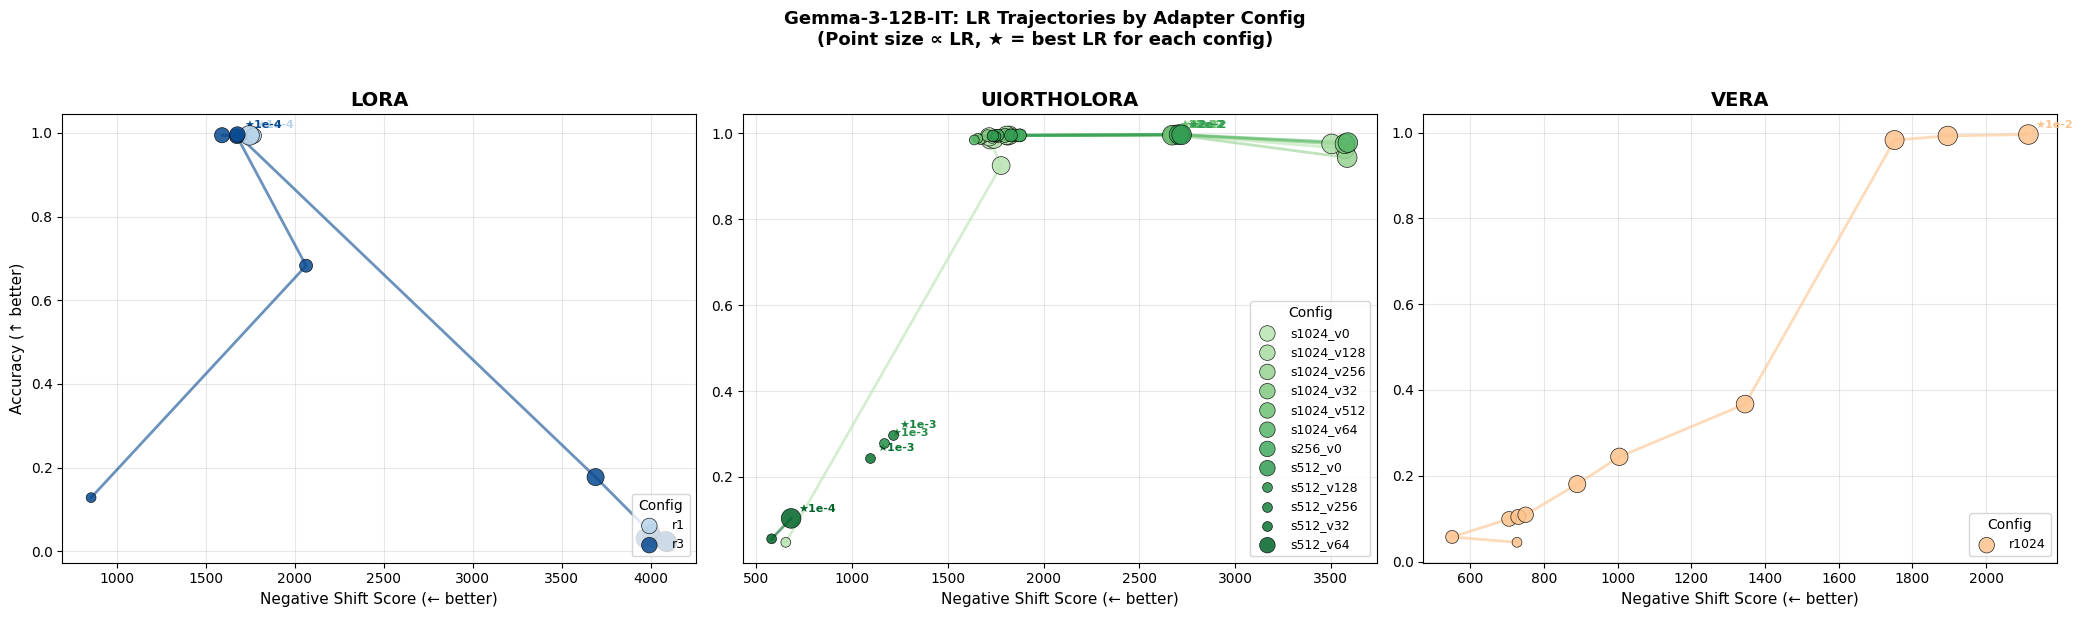

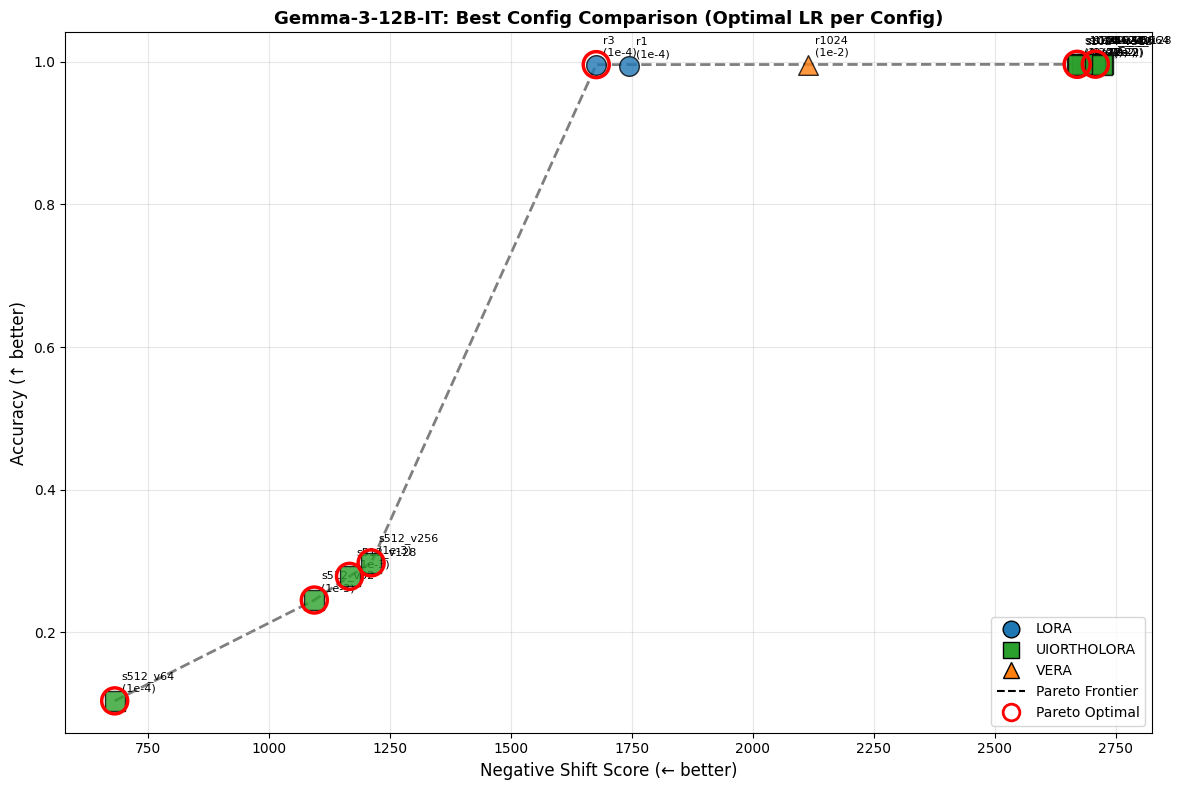

In [7]:
run_improved_analysis(
    csv_path="adapters_results/threshold_0.6/adapter_results_gemma-3-12b-it.csv",
    model_name="Gemma-3-12B-IT"
)

In [8]:
stop

NameError: name 'stop' is not defined


Running analysis for Llama-3.2-3B-Instruct
CSV: adapters_results/threshold_0.8/adapter_results_Llama-3.2-3B-Instruct.csv
Output prefix: graphs/llama-3-2-3b-instruct



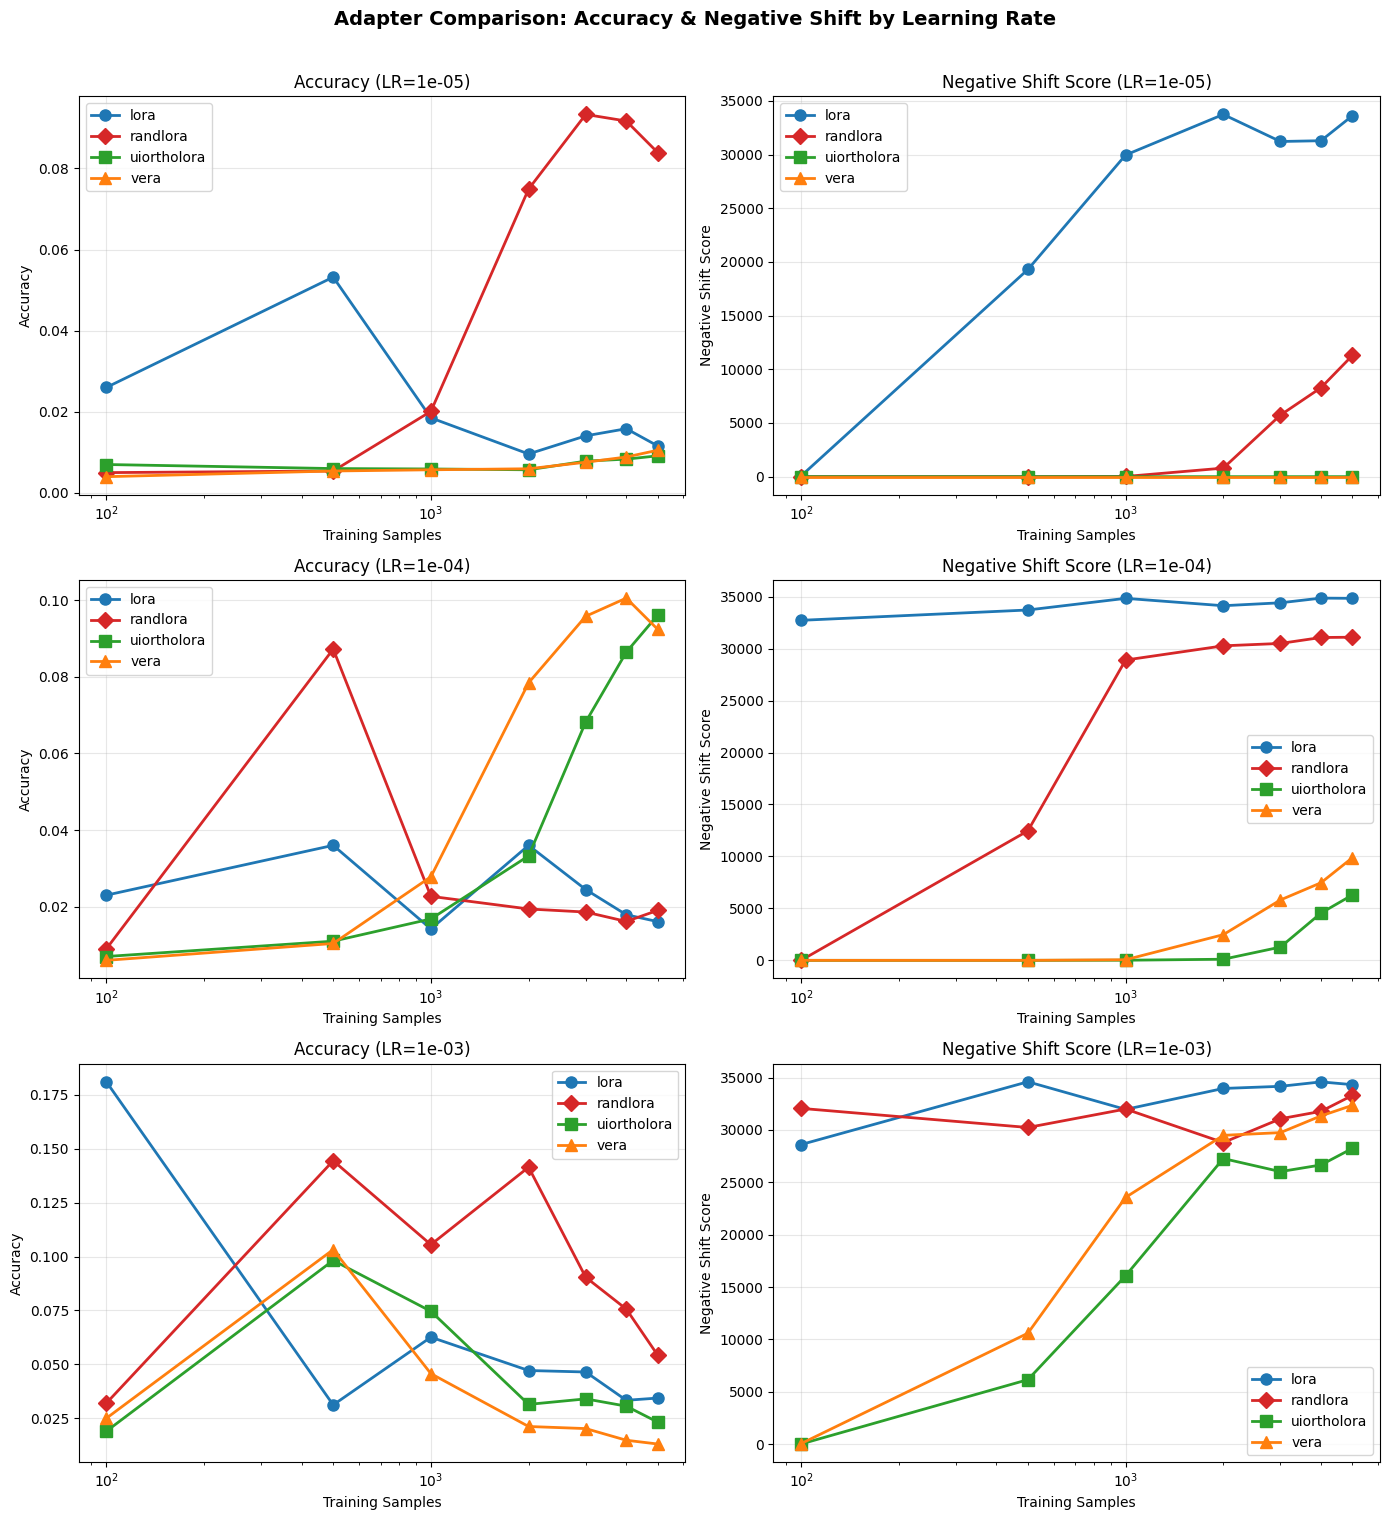


SUMMARY: Llama-3.2-3B-Instruct - Best Configuration per Adapter (by Accuracy)

lora:
  Best Accuracy: 0.1810
  Negative Shift: 28603.4000
  Training Samples: 100
  Learning Rate: 1e-03

randlora:
  Best Accuracy: 0.1444
  Negative Shift: 30235.2000
  Training Samples: 500
  Learning Rate: 1e-03

uiortholora:
  Best Accuracy: 0.0982
  Negative Shift: 6158.7000
  Training Samples: 500
  Learning Rate: 1e-03

vera:
  Best Accuracy: 0.1032
  Negative Shift: 10593.1000
  Training Samples: 500
  Learning Rate: 1e-03

SUMMARY: Llama-3.2-3B-Instruct - Best Configuration per Adapter (by Lowest Negative Shift)

lora:
  Accuracy: 0.0260
  Lowest Negative Shift: 61.4000
  Training Samples: 100
  Learning Rate: 1e-05

randlora:
  Accuracy: 0.0090
  Lowest Negative Shift: 0.0000
  Training Samples: 100
  Learning Rate: 1e-04

uiortholora:
  Accuracy: 0.0070
  Lowest Negative Shift: 0.0000
  Training Samples: 100
  Learning Rate: 1e-04

vera:
  Accuracy: 0.0060
  Lowest Negative Shift: 0.0000
  Trai

In [ ]:
# ============================================================================
# LLAMA-3.2-3B-INSTRUCT ANALYSIS
# ============================================================================

# run_full_analysis(
#     csv_path="adapters_results/threshold_0.2/adapter_results_Llama-3.2-3B-Instruct.csv",
#     output_prefix="graphs/llama-3-2-3b-instruct",
#     model_name="Llama-3.2-3B-Instruct"
# )

# run_full_analysis(
#     csv_path="adapters_results/threshold_0.4/adapter_results_Llama-3.2-3B-Instruct.csv",
#     output_prefix="graphs/llama-3-2-3b-instruct",
#     model_name="Llama-3.2-3B-Instruct"
# )

# run_full_analysis(
#     csv_path="adapters_results/threshold_0.6/adapter_results_Llama-3.2-3B-Instruct.csv",
#     output_prefix="graphs/llama-3-2-3b-instruct",
#     model_name="Llama-3.2-3B-Instruct"
# )

run_full_analysis(
    csv_path="adapters_results/threshold_0.8/adapter_results_Llama-3.2-3B-Instruct.csv",
    output_prefix="graphs/llama-3-2-3b-instruct",
    model_name="Llama-3.2-3B-Instruct"
)


Running analysis for Llama-3.1-8B-Instruct
CSV: adapters_results/threshold_0.8/adapter_results_Llama-3.1-8B-Instruct.csv
Output prefix: graphs/llama-3-1-8b-instruct



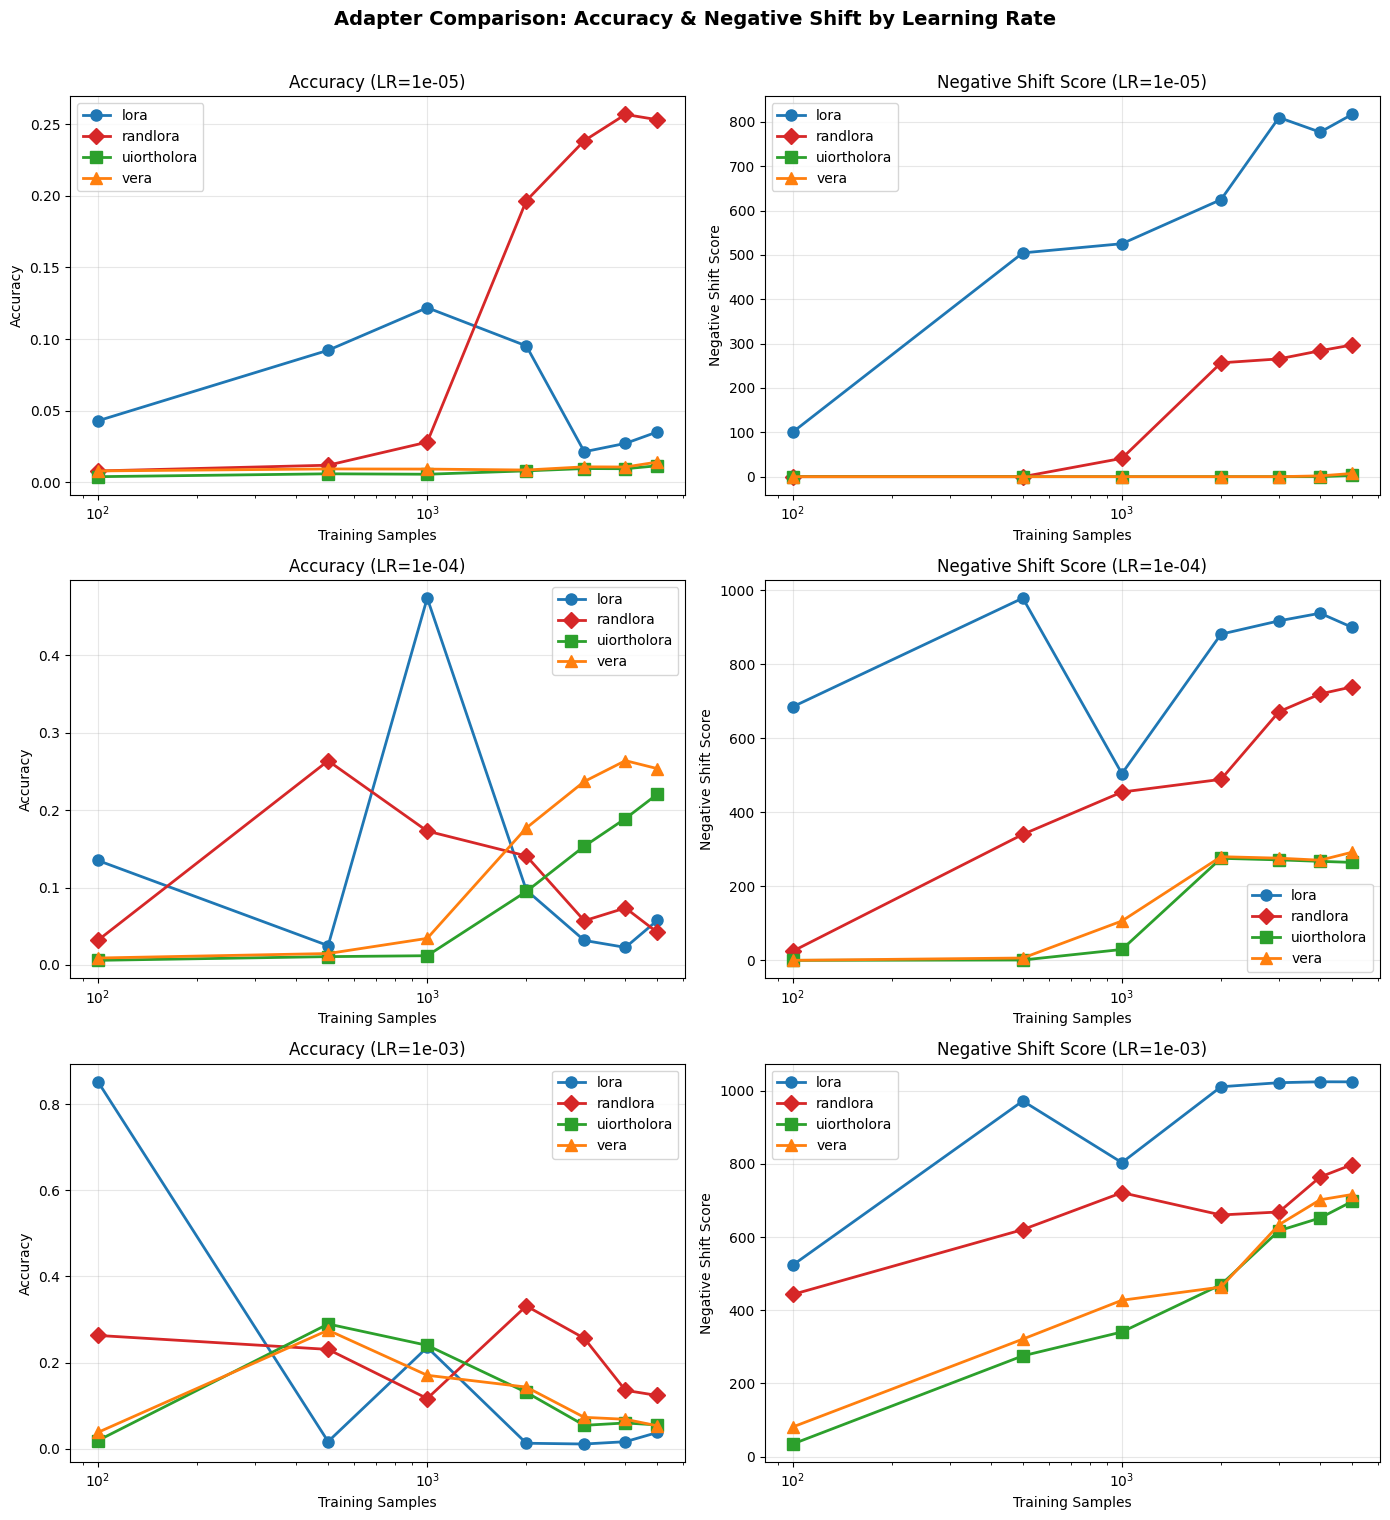


SUMMARY: Llama-3.1-8B-Instruct - Best Configuration per Adapter (by Accuracy)

lora:
  Best Accuracy: 0.8520
  Negative Shift: 523.5000
  Training Samples: 100
  Learning Rate: 1e-03

randlora:
  Best Accuracy: 0.3314
  Negative Shift: 660.6000
  Training Samples: 2000
  Learning Rate: 1e-03

uiortholora:
  Best Accuracy: 0.2896
  Negative Shift: 275.6000
  Training Samples: 500
  Learning Rate: 1e-03

vera:
  Best Accuracy: 0.2752
  Negative Shift: 321.3000
  Training Samples: 500
  Learning Rate: 1e-03

SUMMARY: Llama-3.1-8B-Instruct - Best Configuration per Adapter (by Lowest Negative Shift)

lora:
  Accuracy: 0.0430
  Lowest Negative Shift: 100.4000
  Training Samples: 100
  Learning Rate: 1e-05

randlora:
  Accuracy: 0.0080
  Lowest Negative Shift: 0.0000
  Training Samples: 100
  Learning Rate: 1e-05

uiortholora:
  Accuracy: 0.0060
  Lowest Negative Shift: 0.0000
  Training Samples: 100
  Learning Rate: 1e-04

vera:
  Accuracy: 0.0090
  Lowest Negative Shift: 0.0000
  Training 

In [ ]:
# ============================================================================
# LLAMA-3.2-8B-INSTRUCT ANALYSIS
# ============================================================================

# run_full_analysis(
#     csv_path="adapters_results/threshold_0.2/adapter_results_Llama-3.1-8B-Instruct.csv",
#     output_prefix="graphs/llama-3-1-8b-instruct",
#     model_name="Llama-3.1-8B-Instruct"
# )

# run_full_analysis(
#     csv_path="adapters_results/threshold_0.4/adapter_results_Llama-3.1-8B-Instruct.csv",
#     output_prefix="graphs/llama-3-1-8b-instruct",
#     model_name="Llama-3.1-8B-Instruct"
# )

# run_full_analysis(
#     csv_path="adapters_results/threshold_0.6/adapter_results_Llama-3.1-8B-Instruct.csv",
#     output_prefix="graphs/llama-3-1-8b-instruct",
#     model_name="Llama-3.1-8B-Instruct"
# )

run_full_analysis(
    csv_path="adapters_results/threshold_0.8/adapter_results_Llama-3.1-8B-Instruct.csv",
    output_prefix="graphs/llama-3-1-8b-instruct",
    model_name="Llama-3.1-8B-Instruct"
)

In [ ]:
stop

NameError: name 'stop' is not defined


THRESHOLD = 0.2


Gemma-3-12B-IT
----------------------------------------------------------------------------------------------------

Average Accuracy by Adapter & LR:
lr            0.00001  0.00010  0.00100
adapter_type                           
lora           0.0664   0.0795   0.0376
randlora       0.1268   0.1157   0.1010
uiortholora    0.0121   0.0966   0.1204
vera           0.0127   0.1356   0.1182


Average Negative Shift Score by Adapter & LR:
lr             0.00001    0.00010    0.00100
adapter_type                                
lora         3426.7571  4161.2000  4451.7429
randlora     1100.7167 20471.5143 27066.8571
uiortholora   194.6857  1047.7429 23258.3571
vera          134.4286  1770.1429 17702.6571



Llama-3.1-8B-Instruct
----------------------------------------------------------------------------------------------------

Average Accuracy by Adapter & LR:
lr            0.00001  0.00010  0.00100
adapter_type                           
lora           0.0623   0.1204 

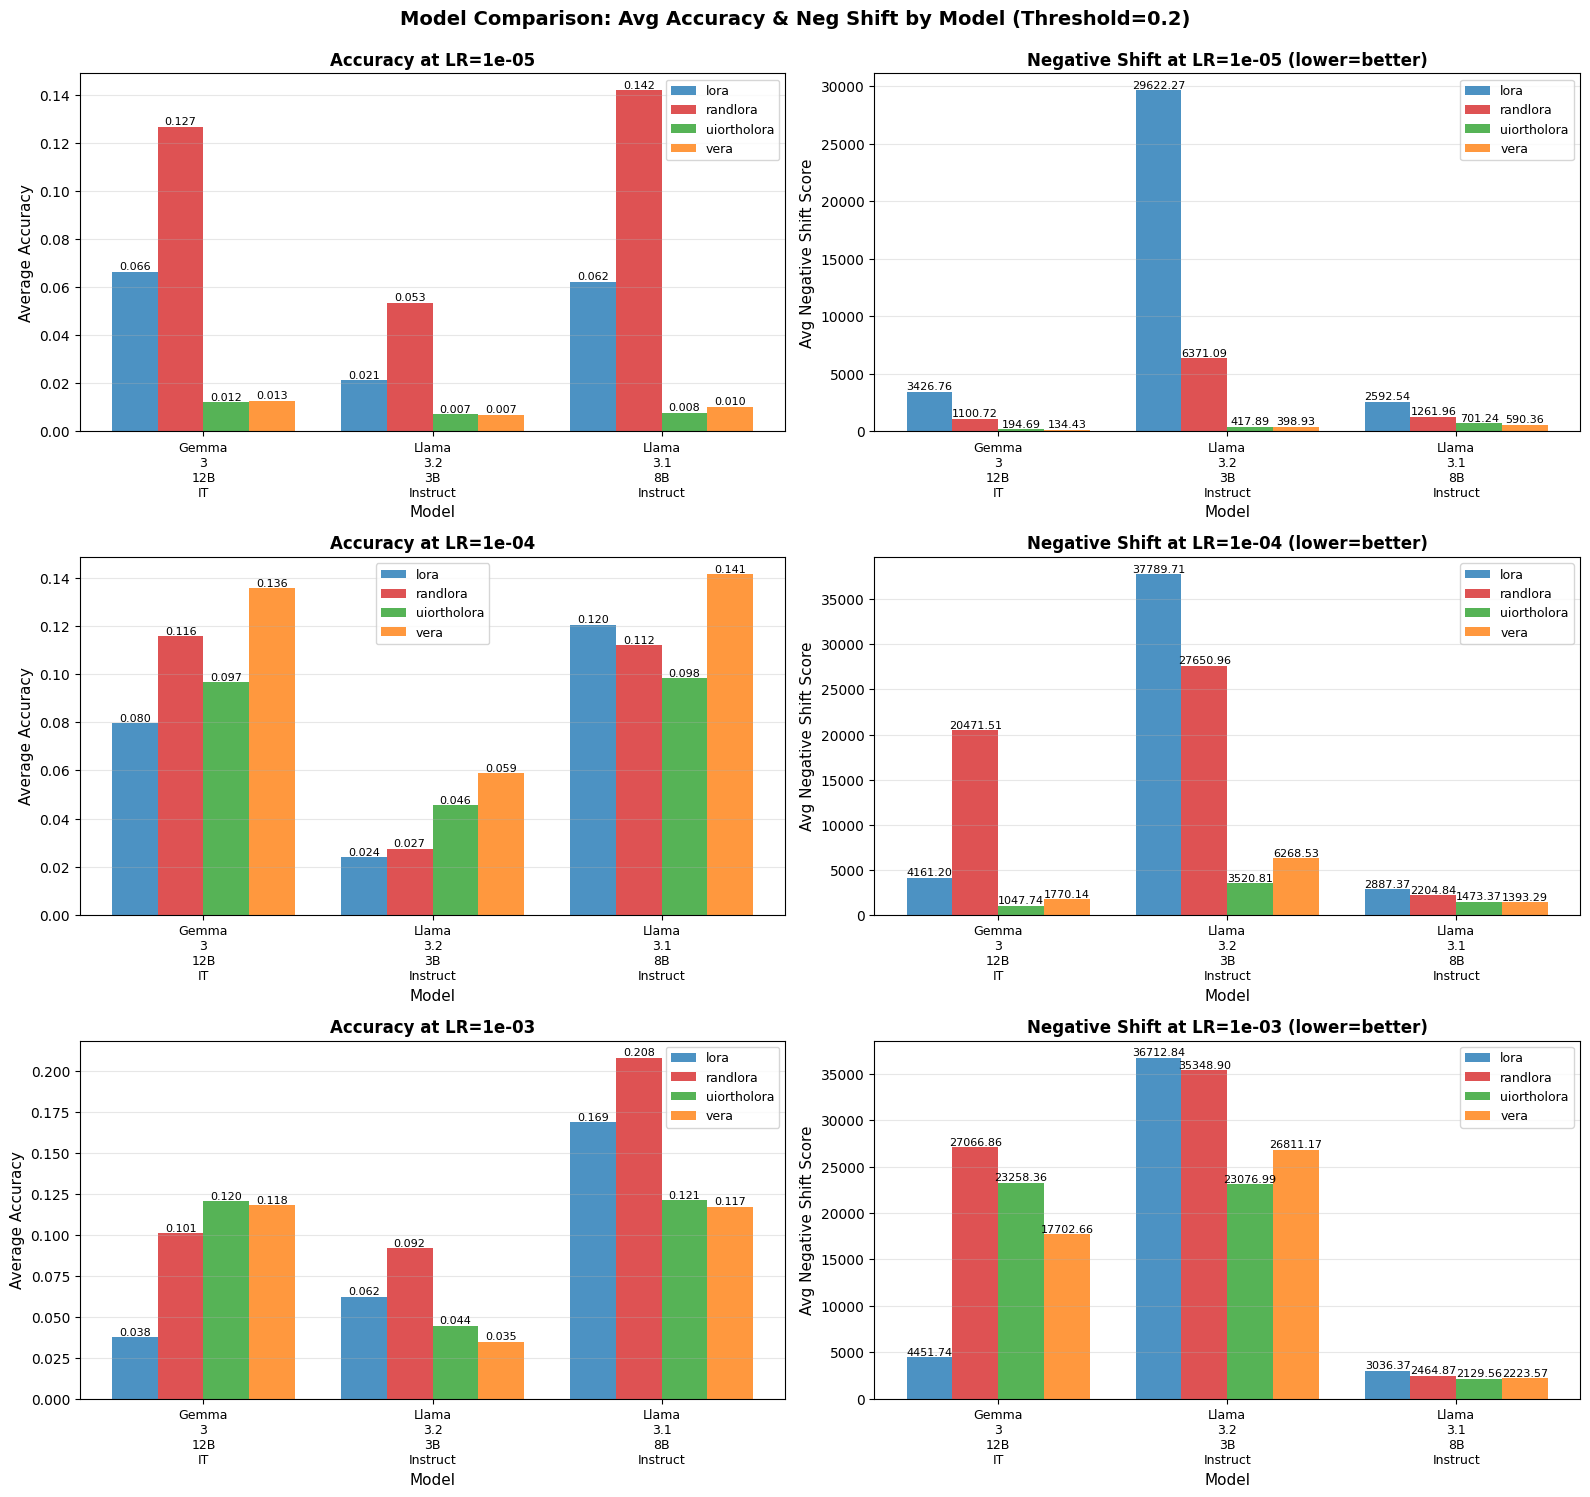

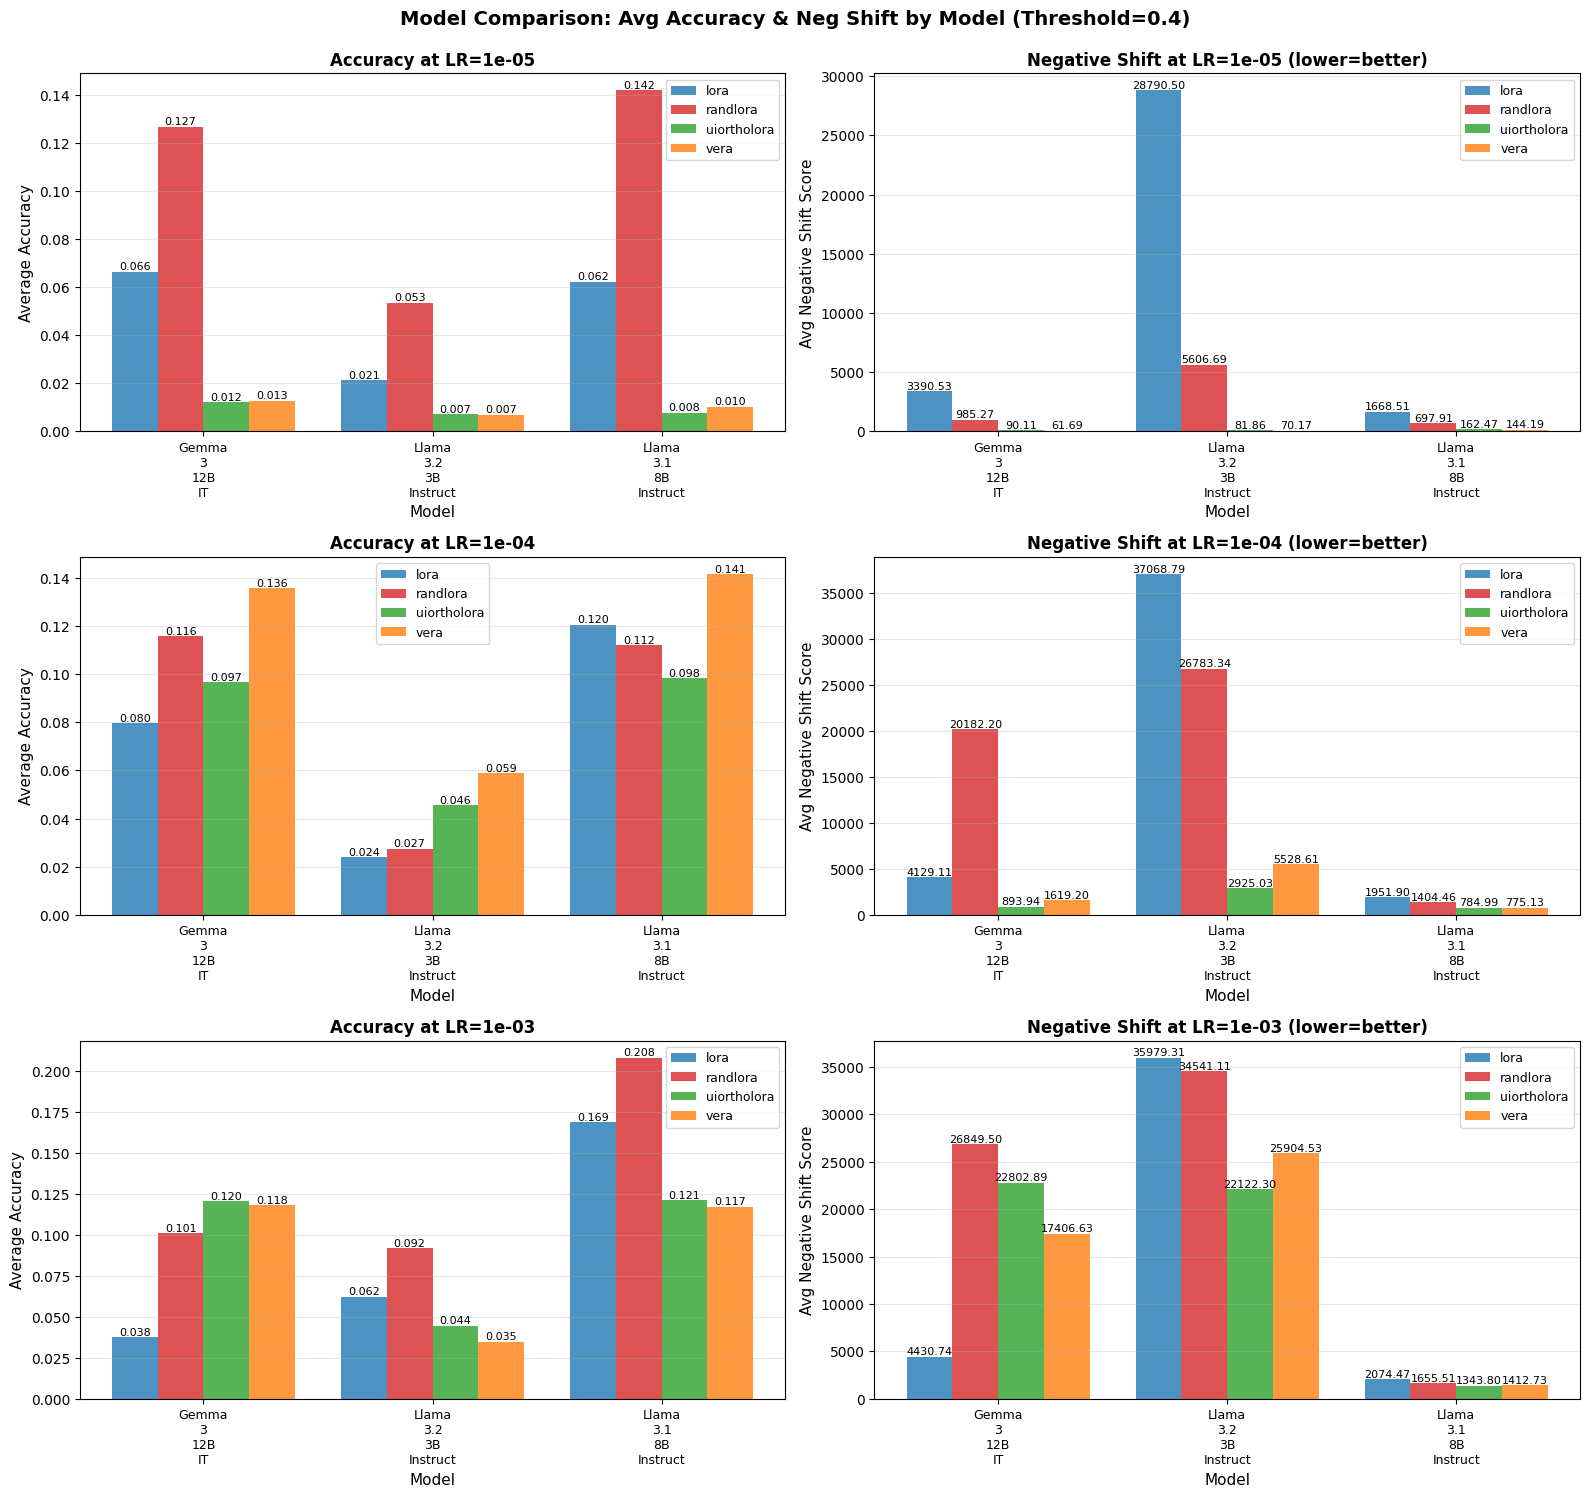

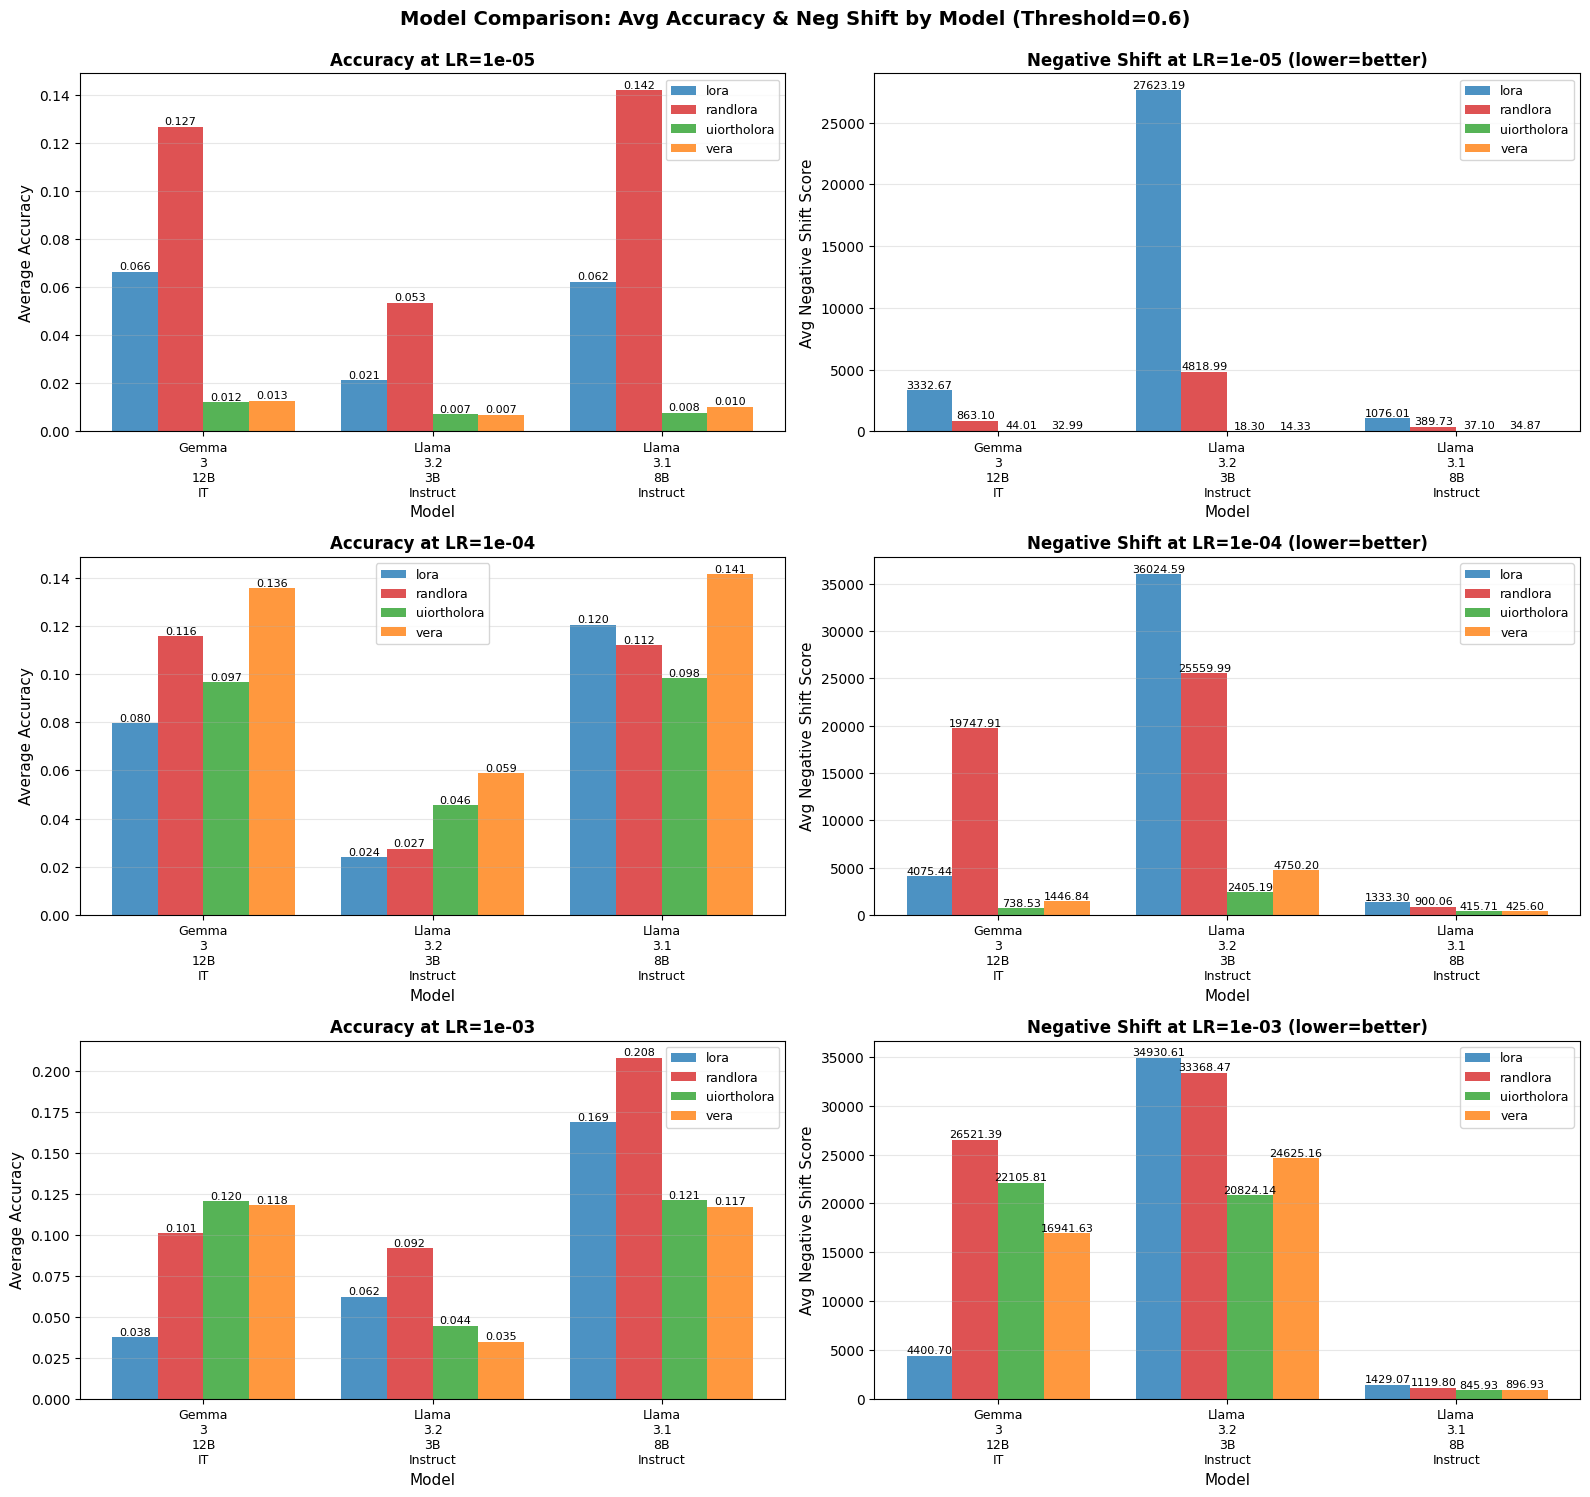

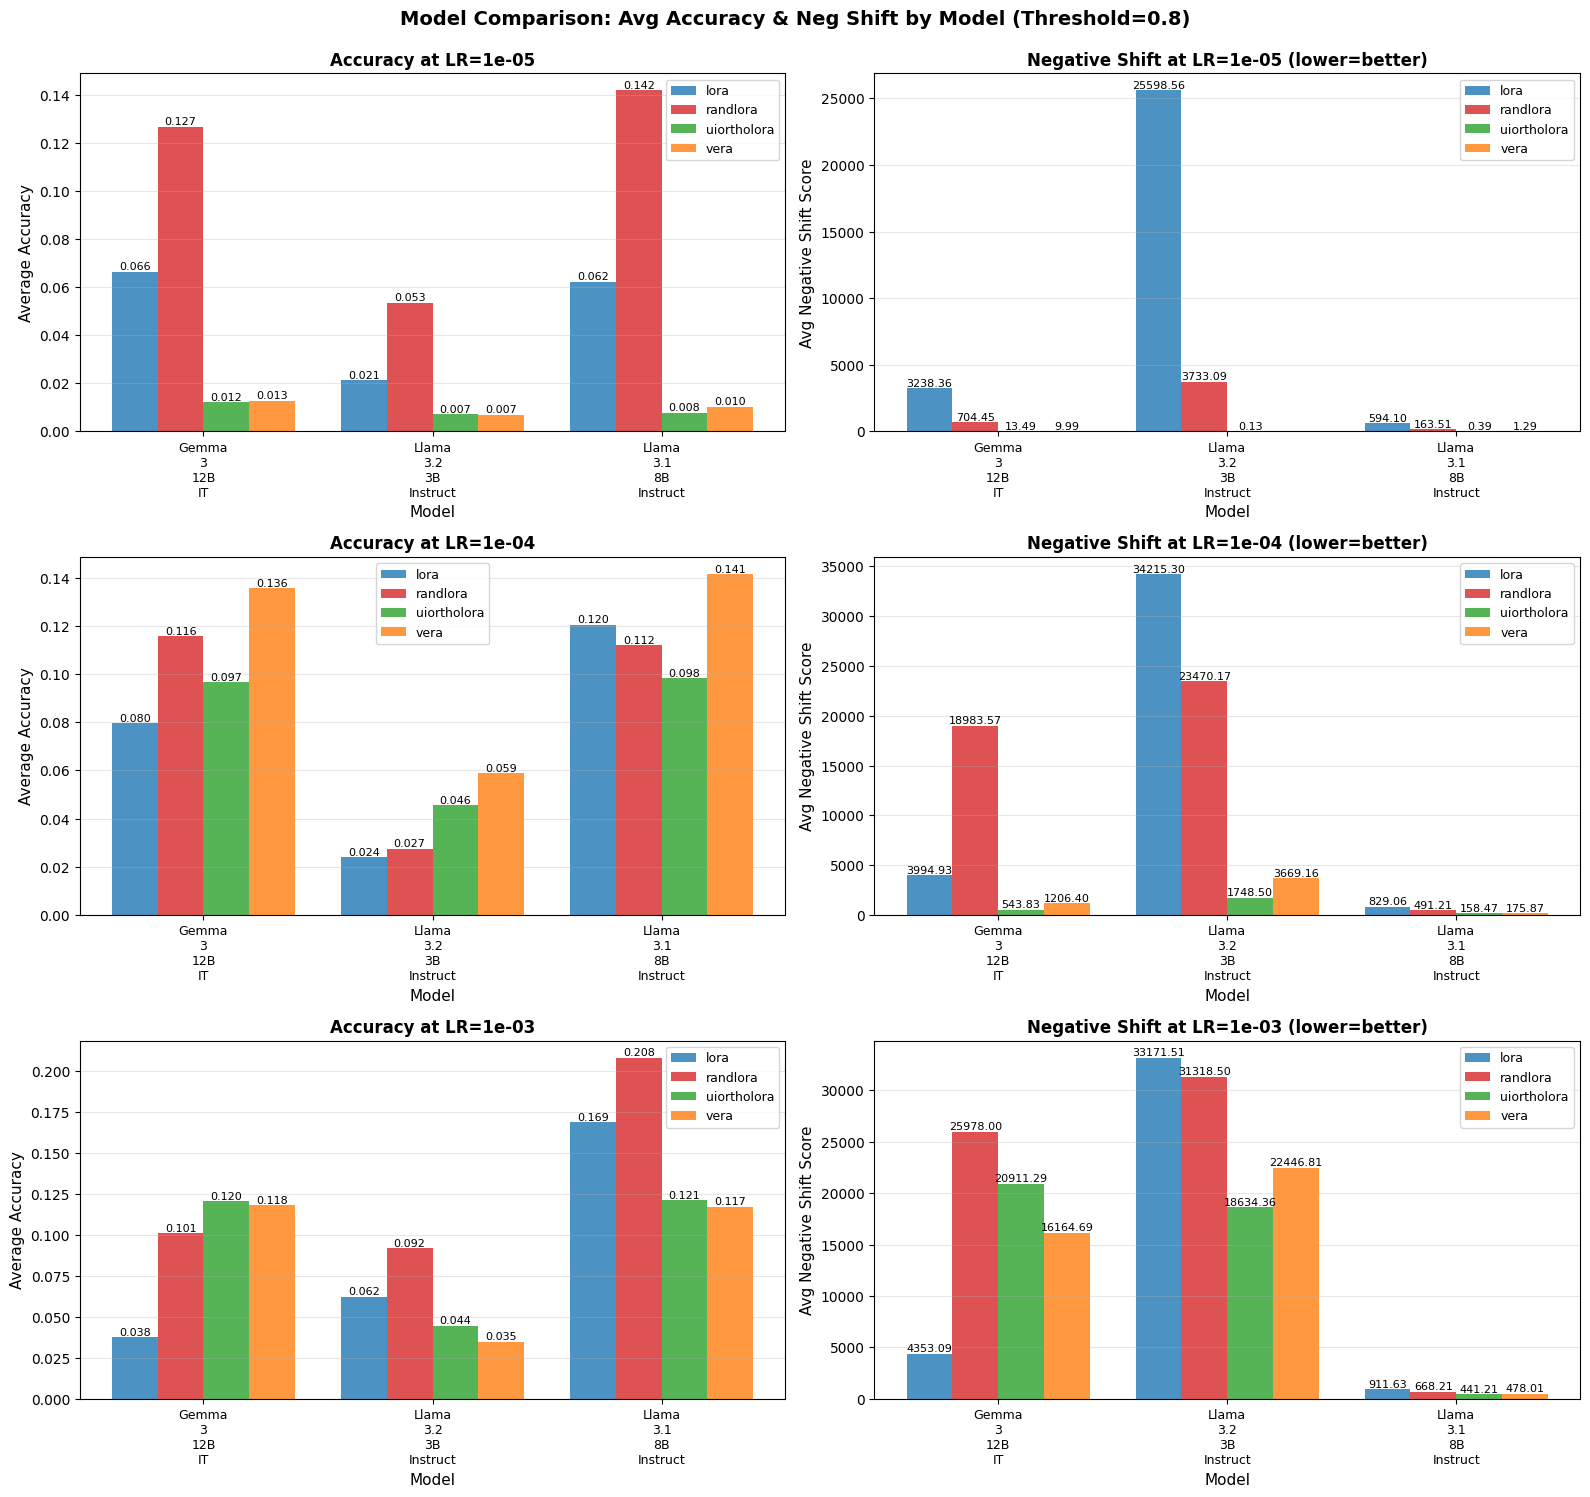


✓ Cross-model comparison complete!


In [ ]:
# ============================================================================
# CROSS-MODEL COMPARISON: Average Accuracy & Negative Shift per LR
# ============================================================================

import os

def compare_models_by_lr_and_threshold():
    """
    Compare average accuracy and negative shift across models, LRs, and thresholds.
    Groups by adapter_type, model, threshold, and lr.
    """
    
    # Define model configurations
    models = [
        {
            'file_name': 'gemma-3-12b-it',
            'display_name': 'Gemma-3-12B-IT'
        },
        {
            'file_name': 'Llama-3.2-3B-Instruct',
            'display_name': 'Llama-3.2-3B-Instruct'
        },
        {
            'file_name': 'Llama-3.1-8B-Instruct',
            'display_name': 'Llama-3.1-8B-Instruct'
        }
    ]
    
    thresholds = [0.2, 0.4, 0.6, 0.8]
    
    # Collect all data
    all_data = []
    
    for model_config in models:
        for threshold in thresholds:
            csv_path = f"adapters_results/threshold_{threshold}/adapter_results_{model_config['file_name']}.csv"
            
            if not os.path.exists(csv_path):
                print(f"⚠️  File not found: {csv_path}")
                continue
            
            df = load_and_prepare_data(csv_path)
            df['model'] = model_config['display_name']
            df['threshold'] = threshold
            all_data.append(df)
    
    if not all_data:
        print("❌ No data found!")
        return
    
    # Combine all data
    combined_df = pd.concat(all_data, ignore_index=True)
    
    # Group by model, threshold, adapter_type, and lr
    # Calculate average accuracy and negative shift across training samples
    summary = combined_df.groupby(['model', 'threshold', 'adapter_type', 'lr']).agg({
        'accuracy': 'mean',
        'negative_shift_score': 'mean',
        'negative_shift_count': 'mean',
        'train_samples': 'count'  # Number of configurations
    }).reset_index()
    
    summary.columns = ['model', 'threshold', 'adapter_type', 'lr', 
                       'avg_accuracy', 'avg_neg_shift_score', 'avg_neg_shift_count', 'n_configs']
    
    # Print results per threshold
    for threshold in thresholds:
        print(f"\n{'='*100}")
        print(f"THRESHOLD = {threshold}")
        print(f"{'='*100}\n")
        
        threshold_data = summary[summary['threshold'] == threshold]
        
        for model_name in threshold_data['model'].unique():
            model_data = threshold_data[threshold_data['model'] == model_name]
            
            print(f"\n{model_name}")
            print("-" * 100)
            
            # Pivot for better readability
            pivot_acc = model_data.pivot_table(
                index='adapter_type',
                columns='lr',
                values='avg_accuracy',
                aggfunc='first'
            )
            
            pivot_neg = model_data.pivot_table(
                index='adapter_type',
                columns='lr',
                values='avg_neg_shift_score',
                aggfunc='first'
            )
            
            print("\nAverage Accuracy by Adapter & LR:")
            print(pivot_acc.to_string(float_format=lambda x: f'{x:.4f}'))
            
            print("\n\nAverage Negative Shift Score by Adapter & LR:")
            print(pivot_neg.to_string(float_format=lambda x: f'{x:.4f}'))
            print("\n")
    
    # Create visualization: Grouped bar charts for each threshold
    for threshold in thresholds:
        threshold_data = summary[summary['threshold'] == threshold]
        
        # Get unique learning rates and adapters
        unique_lrs = sorted(threshold_data['lr'].unique())
        adapters = sorted(threshold_data['adapter_type'].unique())
        model_names = [m['display_name'] for m in models]
        
        # Get adapter colors from style function
        get_style = get_adapter_styles()
        adapter_colors = [get_style(adapter)['color'] for adapter in adapters]
        
        # Create figure with subplots for each LR
        n_lrs = len(unique_lrs)
        fig, axes = plt.subplots(n_lrs, 2, figsize=(16, 5 * n_lrs))
        if n_lrs == 1:
            axes = axes.reshape(1, -1)
        
        fig.suptitle(f'Model Comparison: Avg Accuracy & Neg Shift by Model (Threshold={threshold})',
                     fontsize=14, fontweight='bold', y=0.995)
        
        for lr_idx, lr in enumerate(unique_lrs):
            lr_data = threshold_data[threshold_data['lr'] == lr]
            
            # ACCURACY SUBPLOT
            ax_acc = axes[lr_idx, 0]
            
            # X-axis: models, bars: adapters
            x = np.arange(len(model_names))
            width = 0.8 / len(adapters)  # Divide space by number of adapters
            
            for adapter_idx, adapter in enumerate(adapters):
                adapter_lr_data = lr_data[lr_data['adapter_type'] == adapter]
                
                accuracies = []
                for model_name in model_names:
                    model_data = adapter_lr_data[adapter_lr_data['model'] == model_name]
                    if not model_data.empty:
                        accuracies.append(model_data['avg_accuracy'].values[0])
                    else:
                        accuracies.append(0)
                
                offset = width * (adapter_idx - len(adapters)/2 + 0.5)
                bars = ax_acc.bar(x + offset, accuracies, width, 
                                 label=adapter, color=adapter_colors[adapter_idx], alpha=0.8)
                
                # Add value labels on bars
                for bar in bars:
                    height = bar.get_height()
                    if height > 0:
                        ax_acc.text(bar.get_x() + bar.get_width()/2., height,
                                   f'{height:.3f}',
                                   ha='center', va='bottom', fontsize=8)
            
            ax_acc.set_xlabel('Model', fontsize=11)
            ax_acc.set_ylabel('Average Accuracy', fontsize=11)
            ax_acc.set_title(f'Accuracy at LR={lr:.0e}', fontsize=12, fontweight='bold')
            ax_acc.set_xticks(x)
            ax_acc.set_xticklabels([m.replace('-', '\n') for m in model_names], fontsize=9)
            ax_acc.legend(loc='best', fontsize=9)
            ax_acc.grid(axis='y', alpha=0.3)
            # Let y-axis scale automatically based on data
            ax_acc.set_ylim(bottom=0)
            
            # NEGATIVE SHIFT SUBPLOT
            ax_neg = axes[lr_idx, 1]
            
            for adapter_idx, adapter in enumerate(adapters):
                adapter_lr_data = lr_data[lr_data['adapter_type'] == adapter]
                
                neg_shifts = []
                for model_name in model_names:
                    model_data = adapter_lr_data[adapter_lr_data['model'] == model_name]
                    if not model_data.empty:
                        neg_shifts.append(model_data['avg_neg_shift_score'].values[0])
                    else:
                        neg_shifts.append(0)
                
                offset = width * (adapter_idx - len(adapters)/2 + 0.5)
                bars = ax_neg.bar(x + offset, neg_shifts, width,
                                 label=adapter, color=adapter_colors[adapter_idx], alpha=0.8)
                
                # Add value labels on bars
                for bar in bars:
                    height = bar.get_height()
                    if height > 0:
                        ax_neg.text(bar.get_x() + bar.get_width()/2., height,
                                   f'{height:.2f}',
                                   ha='center', va='bottom', fontsize=8)
            
            ax_neg.set_xlabel('Model', fontsize=11)
            ax_neg.set_ylabel('Avg Negative Shift Score', fontsize=11)
            ax_neg.set_title(f'Negative Shift at LR={lr:.0e} (lower=better)', fontsize=12, fontweight='bold')
            ax_neg.set_xticks(x)
            ax_neg.set_xticklabels([m.replace('-', '\n') for m in model_names], fontsize=9)
            ax_neg.legend(loc='best', fontsize=9)
            ax_neg.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'graphs/comparison_bars_threshold_{threshold}.png', dpi=150, bbox_inches='tight')
        plt.show()
    
    return summary

# Run the comparison
summary_df = compare_models_by_lr_and_threshold()

print("\n✓ Cross-model comparison complete!")

In [ ]:
##### Archive #####

In [ ]:
# ============================================================================
# REUSABLE VISUALIZATION FUNCTIONS
# ============================================================================

def load_and_prepare_data(csv_path):
    """Load CSV and prepare data for visualization."""
    df = pd.read_csv(csv_path)
    
    # Convert columns to numeric
    for col in ["lr", "rank", "tr_from_name", "tr_actual", "accuracy",
                "negative_shift_count", "negative_shift_score",
                "positive_shift_count", "positive_shift_score"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    
    df["train_samples"] = df["tr_actual"].fillna(df["tr_from_name"])
    
    return df


def get_adapter_styles():
    """Define consistent colors and markers for adapters."""
    adapter_styles = {
        'lora': {'color': '#1f77b4', 'marker': 'o'},
        'uiortholora': {'color': '#2ca02c', 'marker': 's'},
        'vera': {'color': '#ff7f0e', 'marker': '^'},
        'randlora': {'color': '#d62728', 'marker': 'D'},
    }
    
    # Fallback for unknown adapters
    default_colors = plt.cm.tab10(np.linspace(0, 1, 10))
    default_markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p']
    
    def get_style(adapter):
        return adapter_styles.get(adapter.lower(), {'color': 'gray', 'marker': 'o'})
    
    return get_style


def plot_accuracy_negshift_by_lr(df, output_prefix):
    """Plot 1: Combined subplots - Accuracy and Negative Shift per LR."""
    lrs = sorted(df["lr"].dropna().unique())
    adapters = sorted(df["adapter_type"].unique())
    get_style = get_adapter_styles()
    
    fig, axes = plt.subplots(len(lrs), 2, figsize=(14, 5 * len(lrs)), squeeze=False)
    fig.suptitle('Adapter Comparison: Accuracy & Negative Shift by Learning Rate', 
                 fontsize=14, fontweight='bold', y=1.01)
    
    for i, lr in enumerate(lrs):
        sub = df[df["lr"] == lr].copy().sort_values("train_samples")
        
        ax_acc = axes[i, 0]
        ax_neg = axes[i, 1]
        
        for adapter in adapters:
            sub_ad = sub[sub["adapter_type"] == adapter]
            if sub_ad.empty:
                continue
            
            style = get_style(adapter)
            
            ax_acc.plot(sub_ad["train_samples"], sub_ad["accuracy"],
                        marker=style['marker'], color=style['color'],
                        label=adapter, linewidth=2, markersize=8)
            
            ax_neg.plot(sub_ad["train_samples"], sub_ad["negative_shift_score"],
                        marker=style['marker'], color=style['color'],
                        label=adapter, linewidth=2, markersize=8)
        
        ax_acc.set_xlabel("Training Samples")
        ax_acc.set_ylabel("Accuracy")
        ax_acc.set_title(f"Accuracy (LR={lr:.0e})")
        ax_acc.legend(loc='best')
        ax_acc.grid(True, alpha=0.3)
        ax_acc.set_xscale('log')
        
        ax_neg.set_xlabel("Training Samples")
        ax_neg.set_ylabel("Negative Shift Score")
        ax_neg.set_title(f"Negative Shift Score (LR={lr:.0e})")
        ax_neg.legend(loc='best')
        ax_neg.grid(True, alpha=0.3)
        ax_neg.set_xscale('log')
    
    plt.tight_layout()
    plt.savefig(f'{output_prefix}_acc_negshift_by_lr.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_tradeoff_scatter(df, output_prefix):
    """Plot 2: Accuracy vs Negative Shift Trade-off (scatter plot per LR)."""
    lrs = sorted(df["lr"].dropna().unique())
    adapters = sorted(df["adapter_type"].unique())
    get_style = get_adapter_styles()
    
    fig, axes = plt.subplots(1, len(lrs), figsize=(6 * len(lrs), 5), squeeze=False)
    fig.suptitle('Trade-off: Accuracy vs Negative Shift Score', 
                  fontsize=14, fontweight='bold', y=1.02)
    
    for i, lr in enumerate(lrs):
        ax = axes[0, i]
        sub = df[df["lr"] == lr]
        
        for adapter in adapters:
            sub_ad = sub[sub["adapter_type"] == adapter]
            if sub_ad.empty:
                continue
            
            style = get_style(adapter)
            
            # Size points by training samples
            sizes = 50 + (sub_ad["train_samples"] / sub_ad["train_samples"].max()) * 200
            
            scatter = ax.scatter(sub_ad["negative_shift_score"], sub_ad["accuracy"],
                                c=[style['color']] * len(sub_ad),
                                marker=style['marker'],
                                s=sizes,
                                label=adapter,
                                alpha=0.7,
                                edgecolors='black',
                                linewidths=0.5)
        
        ax.set_xlabel("Negative Shift Score (lower is better)")
        ax.set_ylabel("Accuracy (higher is better)")
        ax.set_title(f"LR={lr:.0e}")
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
        
        # Add ideal direction arrow
        ax.annotate('', xy=(ax.get_xlim()[0] + 0.1, ax.get_ylim()[1] - 0.02),
                    xytext=(ax.get_xlim()[1] - 0.1, ax.get_ylim()[0] + 0.02),
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1.5, ls='--'))
        ax.text(0.05, 0.95, '← Better', transform=ax.transAxes, fontsize=9, 
                color='gray', va='top')
    
    plt.tight_layout()
    plt.savefig(f'{output_prefix}_tradeoff_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_radar_comparison(df, lr, output_prefix):
    """Plot radar/spider chart comparing adapters at a specific LR."""
    sub = df[df["lr"] == lr]
    adapters = sorted(df["adapter_type"].unique())
    get_style = get_adapter_styles()
    
    # Metrics to compare (normalized)
    metrics = ['accuracy', 'negative_shift_score', 'positive_shift_score']
    metric_labels = ['Accuracy\n(↑ better)', 'Neg Shift\n(↓ better)', 'Pos Shift\n(↑ better)']
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]  # Complete the loop
    
    for adapter in adapters:
        sub_ad = sub[sub["adapter_type"] == adapter]
        if sub_ad.empty:
            continue
        
        # Use mean across training samples for this comparison
        values = []
        for m in metrics:
            val = sub_ad[m].mean()
            # Normalize: for negative_shift, invert so higher is better
            if m == 'negative_shift_score':
                val = 1 - (val / df[m].max()) if df[m].max() > 0 else 0
            else:
                val = val / df[m].max() if df[m].max() > 0 else 0
            values.append(val)
        
        values += values[:1]  # Complete the loop
        
        style = get_style(adapter)
        ax.plot(angles, values, 'o-', linewidth=2, label=adapter,
                color=style['color'], markersize=6)
        ax.fill(angles, values, alpha=0.15, color=style['color'])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metric_labels)
    ax.set_title(f'Adapter Comparison at LR={lr:.0e}\n(Normalized, outer = better)', 
                 fontsize=12, fontweight='bold', y=1.1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    
    plt.tight_layout()
    plt.savefig(f'{output_prefix}_radar_lr{lr:.0e}.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_all_radars(df, output_prefix):
    """Plot radar charts for all learning rates."""
    lrs = sorted(df["lr"].dropna().unique())
    for lr in lrs:
        plot_radar_comparison(df, lr, output_prefix)


def print_summary_tables(df, model_name):
    """Print summary tables for best configurations."""
    adapters = sorted(df["adapter_type"].unique())
    
    print("\n" + "=" * 90)
    print(f"SUMMARY: {model_name} - Best Configuration per Adapter (by Accuracy)")
    print("=" * 90)
    
    for adapter in adapters:
        adapter_data = df[df['adapter_type'] == adapter]
        if len(adapter_data) > 0:
            best_row = adapter_data.loc[adapter_data['accuracy'].idxmax()]
            print(f"\n{adapter}:")
            print(f"  Best Accuracy: {best_row['accuracy']:.4f}")
            print(f"  Negative Shift: {best_row['negative_shift_score']:.4f}")
            print(f"  Training Samples: {int(best_row['train_samples'])}")
            print(f"  Learning Rate: {best_row['lr']:.0e}")
    
    print("\n" + "=" * 90)
    print(f"SUMMARY: {model_name} - Best Configuration per Adapter (by Lowest Negative Shift)")
    print("=" * 90)
    
    for adapter in adapters:
        adapter_data = df[df['adapter_type'] == adapter]
        if len(adapter_data) > 0:
            best_row = adapter_data.loc[adapter_data['negative_shift_score'].idxmin()]
            print(f"\n{adapter}:")
            print(f"  Accuracy: {best_row['accuracy']:.4f}")
            print(f"  Lowest Negative Shift: {best_row['negative_shift_score']:.4f}")
            print(f"  Training Samples: {int(best_row['train_samples'])}")
            print(f"  Learning Rate: {best_row['lr']:.0e}")


def run_full_analysis(csv_path, output_prefix, model_name):
    """
    Run complete analysis pipeline for a given CSV file.
    
    Args:
        csv_path: Path to the CSV file
        output_prefix: Prefix for output files (e.g., 'gemma', 'llama-3b')
        model_name: Model name for display (e.g., 'Gemma-3-12B-IT')
    """
    print(f"\n{'='*90}")
    print(f"Running analysis for {model_name}")
    print(f"CSV: {csv_path}")
    print(f"Output prefix: {output_prefix}")
    print(f"{'='*90}\n")
    
    # Load and prepare data
    df = load_and_prepare_data(csv_path)
    
    # Generate all plots
    plot_accuracy_negshift_by_lr(df, output_prefix)
    # plot_tradeoff_scatter(df, output_prefix)
    # plot_all_radars(df, output_prefix)
    
    # Print summary tables
    # print_summary_tables(df, model_name)
    plot_tradeoff_scatter(df, output_prefix)

    # print(f"\n{'='*90}")
    # print(f"Analysis complete for {model_name}")
    # print(f"{'='*90}\n")

print("✓ Reusable visualization functions loaded successfully!")